<div style="background: linear-gradient(135deg, #1a1a2e 0%, #16213e 50%, #0f3460 100%); padding: 40px; border-radius: 16px; text-align: center; margin-bottom: 20px;">
  <h1 style="color: #e94560; font-size: 2.6em; margin:0; font-family: 'Georgia', serif; text-shadow: 2px 2px 8px #000;">
    📊 Data Validation & Quality
  </h1>
  <h2 style="color: #a8dadc; font-size: 1.4em; margin-top: 10px; font-family: 'Georgia', serif;">
    Lecture 03 — Dimensions 5 through 8
  </h2>
  <hr style="border: 1px solid #e94560; width: 60%; margin: 20px auto;">
  <p style="color: #f0f0f0; font-size: 1.05em;">
    <strong style="color:#e94560;">Dimension 5:</strong> Outlier Detection &nbsp;|&nbsp;
    <strong style="color:#4db6ac;">Dimension 6:</strong> Timeliness &nbsp;|&nbsp;
    <strong style="color:#ffb74d;">Dimension 7:</strong> Distribution Profile &nbsp;|&nbsp;
    <strong style="color:#ba68c8;">Dimension 8:</strong> Relationships &amp; Correlation
  </p>
</div>


## 📦 Required Imports

All libraries used throughout this notebook are imported here. Run this cell first.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from scipy import stats
from scipy.stats import zscore, skew, kurtosis, kstest
from sklearn.ensemble import IsolationForest
import warnings

warnings.filterwarnings('ignore')

# ── Notebook-wide style ────────────────────────────────────────────────────
plt.rcParams.update(
    {
        'figure.facecolor': '#f9f9f9',
        'axes.facecolor': '#ffffff',
        'axes.grid': True,
        'grid.alpha': 0.35,
        'axes.spines.top': False,
        'axes.spines.right': False,
        'font.size': 12,
    }
)
print("✅ All imports successful!")

✅ All imports successful!



---
<div style="background: linear-gradient(90deg, #e94560 0%, #c62a47 100%); padding: 18px 28px; border-radius: 10px;">
  <h1 style="color: white; margin: 0; font-size: 2em;">🔴 Dimension 5 — Outlier Detection</h1>
</div>

### What is an Outlier?

An **outlier** is a data point that differs significantly from other observations. In data quality, outliers are important because they can:

- 🚨 Indicate **data entry errors** (e.g., age = 999)
- 🚨 Indicate **measurement errors** (e.g., sensor malfunction)
- ✅ Be **genuine rare events** worth keeping (e.g., a fraudulent transaction)

> **"If customer purchase amounts typically range from \$10–\$100, a transaction of \$50,000 warrants investigation."**

### Three Key Methods Covered:

| Method | Best For | Assumption |
|---|---|---|
| **Z-Score** | Normally distributed data | Data is roughly bell-shaped |
| **IQR (Interquartile Range)** | Skewed / univariate data | No distributional assumption |
| **Isolation Forest** | Multi-dimensional, complex datasets | No assumption |



---
## 📐 Method 1: Z-Score

### Formula

$$z = \frac{x - \mu}{\sigma}$$

Where:
- $x$ = individual value
- $\mu$ = mean of the dataset
- $\sigma$ = standard deviation

### Interpretation

| Z-Score Range | Meaning |
|---|---|
| $-2 \leq z \leq 2$ | Normal (covers ~95.4% of data) |
| $-3 \leq z \leq 3$ | Acceptable edge (covers ~99.7% of data) |
| $\|z\| > 3$ | **Likely outlier** ← typical threshold |
| $\|z\| > 2$ | **Suspicious** ← stricter threshold |

> **Range of z-score:** $(-\infty, +\infty)$ — but practically, most normal data falls within $\pm 3$.

### Parameters of `scipy.stats.zscore()`

```python
zscore(a, axis=0, ddof=0, nan_policy='propagate')
```

| Parameter | Options | Meaning |
|---|---|---|
| `a` | array-like | Input data |
| `axis` | `0` (column-wise), `1` (row-wise) | Which axis to compute z-scores along |
| `ddof` | `0` (population), `1` (sample) | Degrees of freedom for std |
| `nan_policy` | `'propagate'`, `'raise'`, `'omit'` | How to handle NaN values |


In [2]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# EXAMPLE 1: Employee Salaries — Clean, Nearly Normal Data
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
print("=" * 60)
print("EXAMPLE 1 — Employee Salaries (mostly normal, one extreme error)")
print("=" * 60)

salaries_df = pd.DataFrame(
    {
        'employee_id': [
            'E01',
            'E02',
            'E03',
            'E04',
            'E05',
            'E06',
            'E07',
            'E08',
            'E09',
            'E10',
        ],
        'name': [
            'Ali',
            'Nour',
            'Sara',
            'Karim',
            'Hana',
            'Omar',
            'Lina',
            'Tarek',
            'Mona',
            'Yass',
        ],
        'salary_USD': [4200, 4500, 4800, 5100, 5200, 5300, 5400, 5600, 5900, 95000],
        #                                                                     ^^^^ data entry error
    }
)

salaries_df['z_score'] = zscore(salaries_df['salary_USD'], ddof=1)
salaries_df['is_outlier_z3'] = np.abs(salaries_df['z_score']) > 3
salaries_df['is_outlier_z2'] = np.abs(salaries_df['z_score']) > 2

print("\n📋 Full DataFrame with Z-Scores:")
print(salaries_df.to_string(index=False))

print(f"\n📊 Mean salary  : ${salaries_df['salary_USD'].mean():,.0f}")
print(f"📊 Std deviation: ${salaries_df['salary_USD'].std():,.0f}")
print(f"\n🚨 Outliers (|z| > 3): {salaries_df['is_outlier_z3'].sum()} record(s)")
print(
    salaries_df[salaries_df['is_outlier_z3']][
        ['name', 'salary_USD', 'z_score']
    ].to_string(index=False)
)

EXAMPLE 1 — Employee Salaries (mostly normal, one extreme error)

📋 Full DataFrame with Z-Scores:
employee_id  name  salary_USD   z_score  is_outlier_z3  is_outlier_z2
        E01   Ali        4200 -0.348226          False          False
        E02  Nour        4500 -0.337673          False          False
        E03  Sara        4800 -0.327121          False          False
        E04 Karim        5100 -0.316569          False          False
        E05  Hana        5200 -0.313051          False          False
        E06  Omar        5300 -0.309534          False          False
        E07  Lina        5400 -0.306017          False          False
        E08 Tarek        5600 -0.298982          False          False
        E09  Mona        5900 -0.288429          False          False
        E10  Yass       95000  2.845602          False           True

📊 Mean salary  : $14,100
📊 Std deviation: $28,430

🚨 Outliers (|z| > 3): 0 record(s)
Empty DataFrame
Columns: [name, salary_USD, z_

*Are the previous mean and stdev logical to you?*

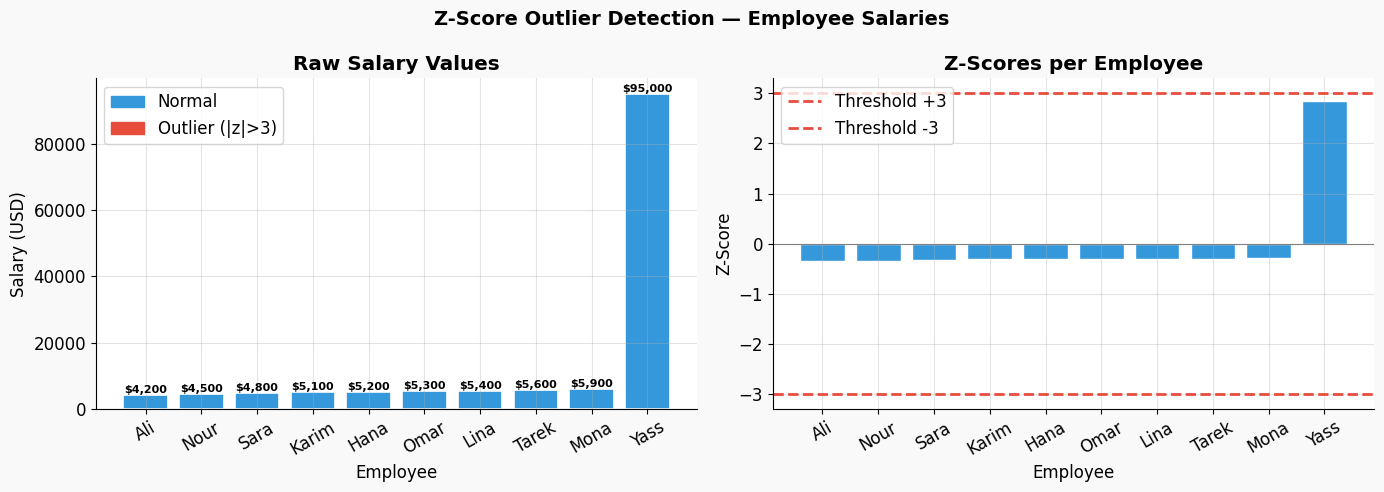

In [3]:
# ── Visualization ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    "Z-Score Outlier Detection — Employee Salaries", fontsize=14, fontweight='bold'
)

colors = ['#e74c3c' if o else '#3498db' for o in salaries_df['is_outlier_z3']]

# Left: raw salary values
ax = axes[0]
bars = ax.bar(
    salaries_df['name'],
    salaries_df['salary_USD'],
    color=colors,
    edgecolor='white',
    linewidth=1.2,
)
ax.set_title("Raw Salary Values", fontweight='bold')
ax.set_ylabel("Salary (USD)")
ax.set_xlabel("Employee")
ax.tick_params(axis='x', rotation=30)
for bar, val in zip(bars, salaries_df['salary_USD']):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 600,
        f"${val:,}",
        ha='center',
        fontsize=8,
        fontweight='bold',
    )
red_patch = mpatches.Patch(color='#e74c3c', label='Outlier (|z|>3)')
blue_patch = mpatches.Patch(color='#3498db', label='Normal')
ax.legend(handles=[blue_patch, red_patch])

# Right: z-scores with threshold lines
ax2 = axes[1]
z_colors = ['#e74c3c' if o else '#3498db' for o in salaries_df['is_outlier_z3']]
ax2.bar(salaries_df['name'], salaries_df['z_score'], color=z_colors, edgecolor='white')
ax2.axhline(y=3, color='#e74c3c', linestyle='--', linewidth=2, label='Threshold +3')
ax2.axhline(y=-3, color='#e74c3c', linestyle='--', linewidth=2, label='Threshold -3')
ax2.axhline(y=0, color='gray', linestyle='-', linewidth=0.8)
ax2.set_title("Z-Scores per Employee", fontweight='bold')
ax2.set_ylabel("Z-Score")
ax2.set_xlabel("Employee")
ax2.tick_params(axis='x', rotation=30)
ax2.legend()

plt.tight_layout()
plt.show()

In [4]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# EXAMPLE 2: Student Exam Scores — Multiple Outliers on Both Sides
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
print("=" * 60)
print("EXAMPLE 2 — Student Exam Scores (outliers on both sides)")
print("=" * 60)

scores_df = pd.DataFrame(
    {
        'student': [
            'S01',
            'S02',
            'S03',
            'S04',
            'S05',
            'S06',
            'S07',
            'S08',
            'S09',
            'S10',
            'S11',
            'S12',
        ],
        'score': [72, 68, 75, 70, 73, 69, 76, 71, 5, 74, 100, 67],
        #                                         ^^     ^^^
        #                                 suspiciously low  suspiciously high
    }
)

scores_df['z_score'] = zscore(scores_df['score'], ddof=1).round(2)
scores_df['|z|'] = scores_df['z_score'].abs().round(2)
scores_df['outlier_z3'] = scores_df['|z|'] > 3

print("\n📋 Score Table with Z-Scores:")
print(scores_df.to_string(index=False))
print(
    f"\n📊 Mean: {scores_df['score'].mean():.1f} | Std: {scores_df['score'].std():.1f}"
)
print(f"\n🚨 Outliers (|z| > 3): {scores_df['outlier_z3'].sum()} record(s)")
print(
    scores_df[scores_df['outlier_z3']][['student', 'score', 'z_score']].to_string(
        index=False
    )
)

EXAMPLE 2 — Student Exam Scores (outliers on both sides)

📋 Score Table with Z-Scores:
student  score  z_score  |z|  outlier_z3
    S01     72     0.17 0.17       False
    S02     68    -0.02 0.02       False
    S03     75     0.31 0.31       False
    S04     70     0.08 0.08       False
    S05     73     0.21 0.21       False
    S06     69     0.03 0.03       False
    S07     76     0.35 0.35       False
    S08     71     0.12 0.12       False
    S09      5    -2.91 2.91       False
    S10     74     0.26 0.26       False
    S11    100     1.46 1.46       False
    S12     67    -0.06 0.06       False

📊 Mean: 68.3 | Std: 21.7

🚨 Outliers (|z| > 3): 0 record(s)
Empty DataFrame
Columns: [student, score, z_score]
Index: []


*NOTE: if the number of normal data is very large compared to the outliers, the avg and std may make more sense.*


---
## 📦 Method 2: IQR — Interquartile Range

The IQR method is **non-parametric** (makes no assumption about the distribution). It uses the **spread of the middle 50%** of data to define what's "normal".

### How It Works

```
Q1 = 25th percentile  (bottom quarter)
Q3 = 75th percentile  (top quarter)
IQR = Q3 - Q1         (middle 50% span)

Lower bound = Q1 - 1.5 × IQR
Upper bound = Q3 + 1.5 × IQR

Any value BELOW lower_bound or ABOVE upper_bound → Outlier
```

### Visual Intuition (Box Plot)

```
        ←── lower whisker ──→ |____[  Q1 | median | Q3  ]____| ←── upper whisker ──→
                              ↑                               ↑
                         lower_bound                    upper_bound
        ●                                                              ●  ●
      (outlier)                                                    (outliers)
```

### Why 1.5?

> The factor **1.5** was suggested by John Tukey (inventor of the box plot). It captures ~99.3% of normally distributed data. A stricter **3.0** multiplier catches only extreme outliers.

### Parameters of `DataFrame.quantile()`

```python
df['col'].quantile(q=0.25)
```

| Parameter | Options | Meaning |
|---|---|---|
| `q` | `0.0` to `1.0` or list | Which quantile(s) to compute |
| `interpolation` | `'linear'`, `'lower'`, `'higher'`, `'midpoint'`, `'nearest'` | How to interpolate between data points |

**Output:** A scalar (single quantile) or Series (multiple quantiles).


**Difference between quantiles, quartiles, percentiles:**

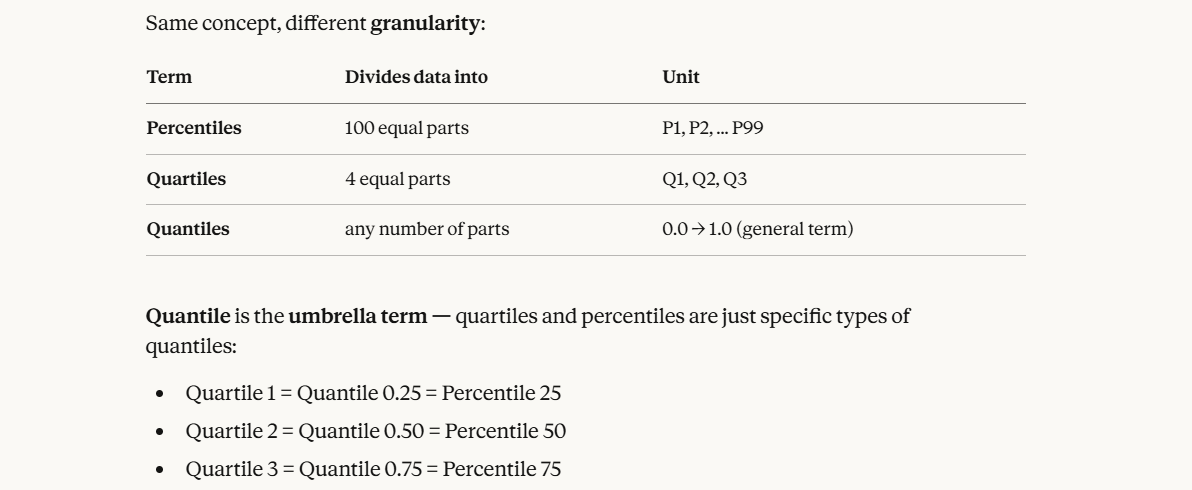

In [5]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# EXAMPLE 1: House Prices — Right-Skewed Data (IQR shines here!)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
print("=" * 60)
print("EXAMPLE 1 — House Prices in EGP (skewed, with luxury outliers)")
print("=" * 60)

houses_df = pd.DataFrame(
    {
        'house_id': [
            'H01',
            'H02',
            'H03',
            'H04',
            'H05',
            'H06',
            'H07',
            'H08',
            'H09',
            'H10',
            'H11',
            'H12',
        ],
        'area_m2': [80, 95, 110, 90, 105, 100, 120, 85, 115, 300, 350, 75],
        'price_EGP': [
            800_000,
            950_000,
            1_100_000,
            900_000,
            1_050_000,
            980_000,
            1_200_000,
            850_000,
            1_150_000,
            8_000_000,
            12_000_000,
            780_000,
        ],
        # last two are luxury mansions — genuine but statistically extreme
    }
)

Q1 = houses_df['price_EGP'].quantile(0.25)
Q3 = houses_df['price_EGP'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

houses_df['outlier_IQR'] = (houses_df['price_EGP'] < lower) | (
    houses_df['price_EGP'] > upper
)

print(f"\n📊 Q1          : EGP {Q1:,.0f}")
print(f"📊 Q3          : EGP {Q3:,.0f}")
print(f"📊 IQR         : EGP {IQR:,.0f}")
print(f"📊 Lower bound : EGP {lower:,.0f}")
print(f"📊 Upper bound : EGP {upper:,.0f}")

print("\n📋 House Price Table:")
print(houses_df.to_string(index=False))

print(f"\n🚨 Outliers detected: {houses_df['outlier_IQR'].sum()}")
print(
    houses_df[houses_df['outlier_IQR']][['house_id', 'area_m2', 'price_EGP']].to_string(
        index=False
    )
)

EXAMPLE 1 — House Prices in EGP (skewed, with luxury outliers)

📊 Q1          : EGP 887,500
📊 Q3          : EGP 1,162,500
📊 IQR         : EGP 275,000
📊 Lower bound : EGP 475,000
📊 Upper bound : EGP 1,575,000

📋 House Price Table:
house_id  area_m2  price_EGP  outlier_IQR
     H01       80     800000        False
     H02       95     950000        False
     H03      110    1100000        False
     H04       90     900000        False
     H05      105    1050000        False
     H06      100     980000        False
     H07      120    1200000        False
     H08       85     850000        False
     H09      115    1150000        False
     H10      300    8000000         True
     H11      350   12000000         True
     H12       75     780000        False

🚨 Outliers detected: 2
house_id  area_m2  price_EGP
     H10      300    8000000
     H11      350   12000000


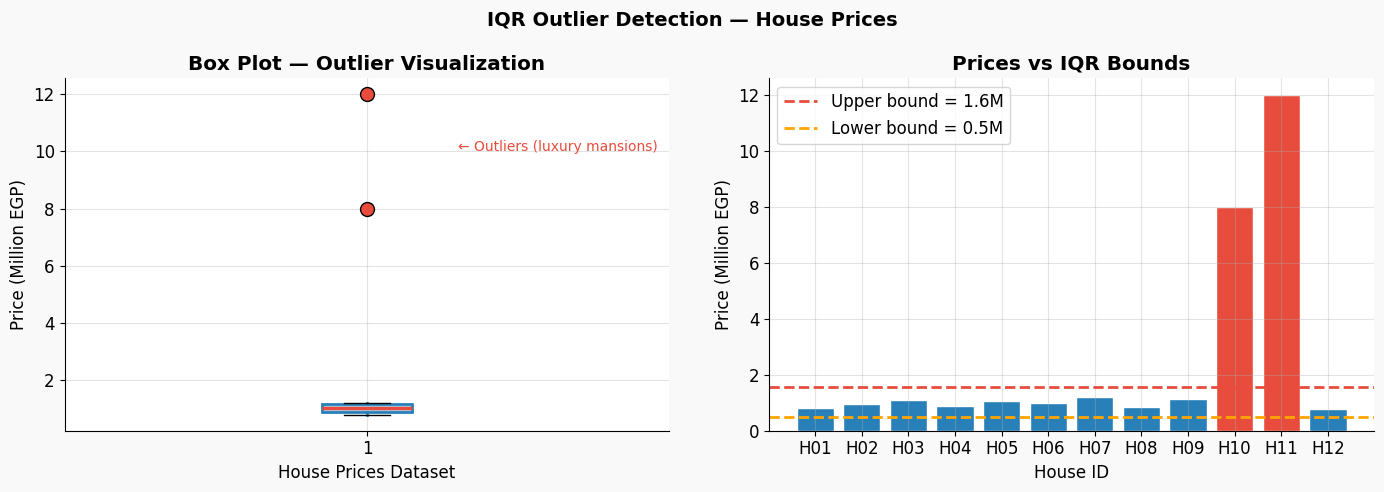


💡 KEY INSIGHT: IQR works well here because the distribution is RIGHT-SKEWED.
   Z-score would be less reliable due to the non-normal shape.


In [6]:
# ── Box Plot Visualization ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("IQR Outlier Detection — House Prices", fontsize=14, fontweight='bold')

# Left: Box Plot
ax = axes[0]
bp = ax.boxplot(
    houses_df['price_EGP'] / 1e6,
    vert=True,
    patch_artist=True,
    notch=False,
    boxprops=dict(facecolor='#aed6f1', color='#2980b9', linewidth=2),
    whiskerprops=dict(color='#2980b9', linewidth=2),
    medianprops=dict(color='#e74c3c', linewidth=2.5),
    flierprops=dict(
        marker='o',
        color='#e74c3c',
        markersize=10,
        markerfacecolor='#e74c3c',
        label='Outlier',
    ),
)
ax.set_title("Box Plot — Outlier Visualization", fontweight='bold')
ax.set_ylabel("Price (Million EGP)")
ax.set_xlabel("House Prices Dataset")
ax.annotate("← Outliers (luxury mansions)", xy=(1.15, 10), fontsize=10, color='#e74c3c')

# Right: Bar chart with outlier coloring
ax2 = axes[1]
colors = ['#e74c3c' if o else '#2980b9' for o in houses_df['outlier_IQR']]
ax2.bar(
    houses_df['house_id'], houses_df['price_EGP'] / 1e6, color=colors, edgecolor='white'
)
ax2.axhline(
    y=upper / 1e6,
    color='#e74c3c',
    linestyle='--',
    linewidth=2,
    label=f'Upper bound = {upper/1e6:.1f}M',
)
ax2.axhline(
    y=lower / 1e6,
    color='orange',
    linestyle='--',
    linewidth=2,
    label=f'Lower bound = {lower/1e6:.1f}M',
)
ax2.set_title("Prices vs IQR Bounds", fontweight='bold')
ax2.set_ylabel("Price (Million EGP)")
ax2.set_xlabel("House ID")
ax2.legend()

plt.tight_layout()
plt.show()
print("\n💡 KEY INSIGHT: IQR works well here because the distribution is RIGHT-SKEWED.")
print("   Z-score would be less reliable due to the non-normal shape.")


---
## 🌲 Method 3: Isolation Forest

### Core Idea

Isolation Forest is a **machine learning** approach for anomaly detection. Instead of building a profile of "normal" and then detecting deviations, it **directly isolates anomalies**.

### How It Works (Step-by-Step)

1. **Pick a random feature** from the dataset.
2. **Pick a random split value** within that feature's min-max range.
3. **Recursively split** until each data point is isolated.
4. **Count the path length** (number of splits) to isolate each point.

> 🔑 **Key Insight:** Anomalies are *rare* and *different*, so they require **fewer splits** to isolate → shorter path lengths → lower anomaly score.

```
Normal point:  Requires 10-15 splits to isolate (deep in the tree)
Anomaly:       Requires 2-3 splits to isolate (isolated quickly near root)
```

### Output Values

| Output | Meaning |
|---|---|
| `+1` | **Inlier** — normal point |
| `-1` | **Outlier** — anomaly detected |

### Key Parameters of `IsolationForest()`

```python
IsolationForest(n_estimators=100, contamination='auto', max_samples='auto',
                max_features=1.0, bootstrap=False, random_state=None)
```

| Parameter | Default | Meaning |
|---|---|---|
| `n_estimators` | `100` | Number of trees to build (more = more robust) |
| `contamination` | `'auto'` | Expected proportion of outliers: `'auto'` or float like `0.05` |
| `max_samples` | `'auto'` | Samples per tree: `'auto'` uses min(256, n_samples) |
| `max_features` | `1.0` | Features per tree (1.0 = use all features) |
| `random_state` | `None` | Seed for reproducibility |

> When `contamination` is a float (e.g., `0.1`), the model flags the top 10% most anomalous points.


In [7]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# EXAMPLE 1: 2D Transaction Data — Where Isolation Forest excels
# (both amount AND hour need to be jointly unusual)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
print("=" * 60)
print("EXAMPLE 1 — Bank Transactions (2 features)")
print("=" * 60)

transactions_df = pd.DataFrame(
    {
        'tx_id': [f'TX{i:02d}' for i in range(1, 14)],
        'amount_USD': [120, 85, 200, 145, 95, 175, 110, 90, 160, 130, 5000, 180, 115],
        'hour_of_day': [10, 14, 11, 9, 15, 12, 10, 16, 13, 11, 3, 14, 10],
        #                                                                     ^^^   ^^^
        #                                              huge amount at 3am = suspicious jointly
    }
)

features = ['amount_USD', 'hour_of_day']

clf = IsolationForest(
    n_estimators=200,  # 200 trees for stable results
    contamination=0.1,  # we expect ~10% outliers
    random_state=42,
)

transactions_df['anomaly_score'] = clf.fit_predict(transactions_df[features])
transactions_df['is_outlier'] = transactions_df['anomaly_score'] == -1

print("\n📋 Transaction Table:")
print(transactions_df.to_string(index=False))
print(f"\n🚨 Anomalies detected: {transactions_df['is_outlier'].sum()}")
print(
    transactions_df[transactions_df['is_outlier']][
        ['tx_id', 'amount_USD', 'hour_of_day']
    ].to_string(index=False)
)

EXAMPLE 1 — Bank Transactions (2 features)

📋 Transaction Table:
tx_id  amount_USD  hour_of_day  anomaly_score  is_outlier
 TX01         120           10              1       False
 TX02          85           14              1       False
 TX03         200           11              1       False
 TX04         145            9              1       False
 TX05          95           15              1       False
 TX06         175           12              1       False
 TX07         110           10              1       False
 TX08          90           16             -1        True
 TX09         160           13              1       False
 TX10         130           11              1       False
 TX11        5000            3             -1        True
 TX12         180           14              1       False
 TX13         115           10              1       False

🚨 Anomalies detected: 2
tx_id  amount_USD  hour_of_day
 TX08          90           16
 TX11        5000            3


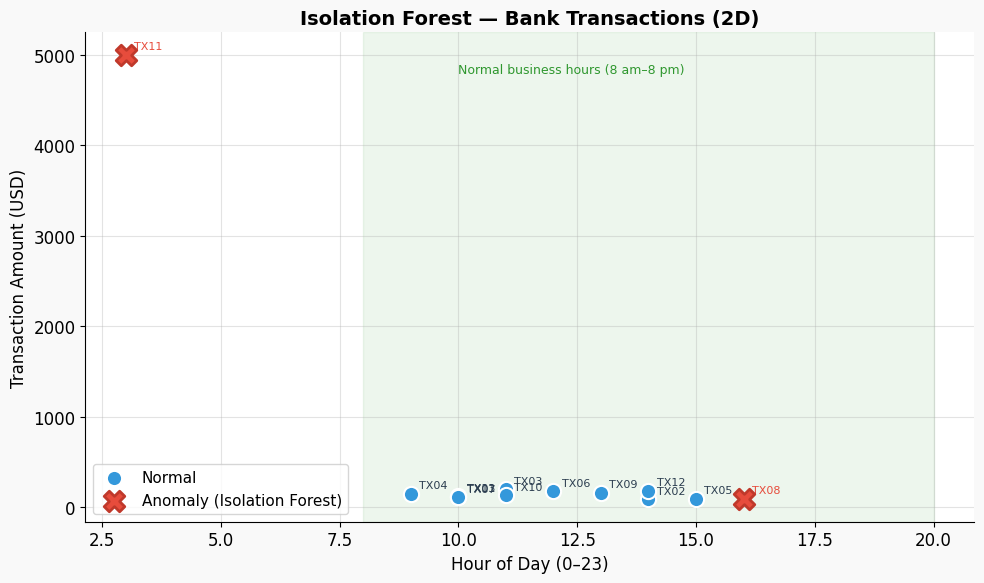


💡 KEY INSIGHT: TX11 ($5000 at 3 AM) is anomalous not just because of amount,
   but because of the COMBINATION of high amount + unusual hour.
   Z-Score or IQR on amount ALONE might miss this context!


In [8]:
# ── 2D Visualization ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

normal = transactions_df[~transactions_df['is_outlier']]
outliers = transactions_df[transactions_df['is_outlier']]

ax.scatter(
    normal['hour_of_day'],
    normal['amount_USD'],
    c='#3498db',
    s=120,
    label='Normal',
    edgecolors='white',
    linewidth=1.5,
    zorder=3,
)
ax.scatter(
    outliers['hour_of_day'],
    outliers['amount_USD'],
    c='#e74c3c',
    s=220,
    marker='X',
    label='Anomaly (Isolation Forest)',
    edgecolors='#c0392b',
    linewidth=2,
    zorder=4,
)

for _, row in transactions_df.iterrows():
    ax.annotate(
        row['tx_id'],
        (row['hour_of_day'], row['amount_USD']),
        textcoords="offset points",
        xytext=(6, 4),
        fontsize=8,
        color='#e74c3c' if row['is_outlier'] else '#2c3e50',
    )

ax.set_title(
    "Isolation Forest — Bank Transactions (2D)", fontsize=14, fontweight='bold'
)
ax.set_xlabel("Hour of Day (0–23)")
ax.set_ylabel("Transaction Amount (USD)")
ax.legend(fontsize=11)

# Shade the "normal business hours" region
ax.axvspan(8, 20, alpha=0.07, color='green', label='_nolegend_')
ax.text(
    10, 4800, "Normal business hours (8 am–8 pm)", color='green', fontsize=9, alpha=0.8
)

plt.tight_layout()
plt.show()
print("\n💡 KEY INSIGHT: TX11 ($5000 at 3 AM) is anomalous not just because of amount,")
print("   but because of the COMBINATION of high amount + unusual hour.")
print("   Z-Score or IQR on amount ALONE might miss this context!")

In [9]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# EXAMPLE 2: 3 features — Student Performance Anomaly Detection
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
print("=" * 60)
print("EXAMPLE 2 — Student Performance (3 features)")
print("=" * 60)

students_df = pd.DataFrame(
    {
        'student': ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L'],
        'study_hrs': [5, 4, 6, 5, 3, 7, 4, 5, 6, 0, 5, 6],
        'attendance': [90, 85, 92, 88, 82, 95, 87, 89, 91, 20, 88, 90],
        'grade': [75, 70, 82, 78, 65, 88, 72, 77, 80, 95, 76, 81],
        #                                             ^^
        #                   0 hrs study + 20% attendance BUT scores 95?  ← anomaly
    }
)

features3 = ['study_hrs', 'attendance', 'grade']
clf3 = IsolationForest(n_estimators=150, contamination=0.1, random_state=42)
students_df['anomaly'] = clf3.fit_predict(students_df[features3])
students_df['is_outlier'] = students_df['anomaly'] == -1

print("\n📋 Student Table:")
print(students_df.to_string(index=False))
print(f"\n🚨 Anomalies: {students_df['is_outlier'].sum()}")
print(
    students_df[students_df['is_outlier']][
        ['student', 'study_hrs', 'attendance', 'grade']
    ].to_string(index=False)
)
print(
    "\n💡 Student J: 0 study hours, 20% attendance, yet scored 95 — a suspicious pattern!"
)

EXAMPLE 2 — Student Performance (3 features)

📋 Student Table:
student  study_hrs  attendance  grade  anomaly  is_outlier
      A          5          90     75        1       False
      B          4          85     70        1       False
      C          6          92     82        1       False
      D          5          88     78        1       False
      E          3          82     65       -1        True
      F          7          95     88        1       False
      G          4          87     72        1       False
      H          5          89     77        1       False
      I          6          91     80        1       False
      J          0          20     95       -1        True
      K          5          88     76        1       False
      L          6          90     81        1       False

🚨 Anomalies: 2
student  study_hrs  attendance  grade
      E          3          82     65
      J          0          20     95

💡 Student J: 0 study hours, 20% attenda


---
## 🔍 Comparing All Three Outlier Methods

| Feature | Z-Score | IQR | Isolation Forest |
|---|---|---|---|
| **Assumption** | Normal distribution | None | None |
| **Univariate / Multivariate** | Univariate | Univariate | **Multivariate** |
| **Skewed data** | ❌ Unreliable | ✅ Good | ✅ Good |
| **Interpretability** | ✅ Very intuitive | ✅ Intuitive | ⚠️ Less interpretable |
| **Speed** | ✅ Fast | ✅ Fast | ⚠️ Slower (ML model) |
| **Detects complex anomalies** | ❌ | ❌ | ✅ |
| **Code complexity** | Simple | Simple | Moderate |

### When to Use Each Method

- 🔵 **Z-Score:** Quick sanity check on approximately normal data (e.g., heights, IQ scores)
- 🟠 **IQR:** Skewed distributions (e.g., income, house prices, purchase amounts)
- 🔴 **Isolation Forest:** Multiple features where the *combination* creates the anomaly



---
<div style="background: linear-gradient(90deg, #00897b 0%, #00695c 100%); padding: 18px 28px; border-radius: 10px;">
  <h1 style="color: white; margin: 0; font-size: 2em;">🕐 Dimension 6 — Timeliness</h1>
</div>

### What is Timeliness?

**Timeliness** validates **time-based properties** of your data. Data can be accurate, complete, and consistent — but if it's stale, it's useless (or harmful) for decision-making.

### What to Validate

| Check | What It Means | Example |
|---|---|---|
| **Data freshness** | Is the latest record recent enough? | Sensor data must arrive within last 5 minutes |
| **Chronological order** | Are timestamps sequential? | Events should not appear before they were triggered |
| **Expected frequency** | Does data arrive at expected rate? | API should produce 100 events/hour |
| **Gap detection** | Are there unexpected holes in time? | Missing day in daily sales records |
| **Duplicate timestamps** | Same moment recorded twice? | Two records with identical timestamp |

### Key pandas/datetime tools

| Function | Purpose |
|---|---|
| `pd.to_datetime()` | Convert strings/integers to datetime |
| `pd.Timestamp.now()` | Get current datetime |
| `pd.Timedelta()` | Create time duration objects |
| `df['ts'].is_monotonic_increasing` | Check if timestamps are in order |
| `df['ts'].diff()` | Time gap between consecutive rows |
| `.dt.total_seconds()` | Convert timedelta to seconds |
| `pd.date_range()` | Generate expected time sequence |


In [ ]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# EXAMPLE 1: IoT Temperature Sensor — Check Freshness & Order
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
print("=" * 60)
print("EXAMPLE 1 — IoT Sensor Readings: Freshness + Order Checks")
print("=" * 60)

sensor_readings = pd.DataFrame(
    {
        'reading_id': [1, 2, 3, 4, 5, 6, 7, 8],
        'timestamp': pd.to_datetime(
            [
                '2026-03-04 08:00:00',
                '2026-03-04 08:05:00',
                '2026-03-04 08:10:00',
                '2026-03-04 08:03:00',  # ← OUT OF ORDER (goes back in time!)
                '2026-03-04 08:20:00',
                '2026-03-04 08:25:00',
                '2026-03-04 08:30:00',
                '2026-03-04 08:35:00',
            ]
        ),
        'temperature_C': [22.1, 22.3, 22.5, 22.2, 22.8, 23.0, 22.9, 23.1],
    }
)

print("\n📋 Raw Sensor Data:")
print(sensor_readings.to_string(index=False))

# ── CHECK 1: Freshness ────────────────────────────────────────────────────
latest_ts = sensor_readings['timestamp'].max()
simulated_now = pd.Timestamp('2026-03-04 09:00:00')  # simulating "now"
age_minutes = (simulated_now - latest_ts).total_seconds() / 60

print(f"\n✅ CHECK 1 — FRESHNESS")
print(f"   Latest record : {latest_ts}")
print(f"   Current time  : {simulated_now}")
print(f"   Data age      : {age_minutes:.0f} minutes")
if age_minutes > 30:
    print("   ⚠️  WARNING: Data is more than 30 minutes old!")
else:
    print("   ✅ Data is fresh (within 30-min threshold)")

# ── CHECK 2: Chronological Order ─────────────────────────────────────────
print(f"\n✅ CHECK 2 — CHRONOLOGICAL ORDER")
is_ordered = sensor_readings['timestamp'].is_monotonic_increasing
print(f"   is_monotonic_increasing = {is_ordered}")
if not is_ordered:
    out_of_order = sensor_readings[
        sensor_readings['timestamp'] < sensor_readings['timestamp'].shift(1)
    ]
    # shift(1) gives you the row above (previous) in the same column.
    # so the whole column data shift(1) means shifted one downward, stating previous of each.
    # col:       10:00 12:00 13:00
    # shift(1):  NaT   10:00 12:00
    print(f"   ⚠️  WARNING: {len(out_of_order)} out-of-order record(s) found!")
    print(out_of_order[['reading_id', 'timestamp']].to_string(index=False))

EXAMPLE 1 — IoT Sensor Readings: Freshness + Order Checks

📋 Raw Sensor Data:
 reading_id           timestamp  temperature_C
          1 2026-03-04 08:00:00           22.1
          2 2026-03-04 08:05:00           22.3
          3 2026-03-04 08:10:00           22.5
          4 2026-03-04 08:03:00           22.2
          5 2026-03-04 08:20:00           22.8
          6 2026-03-04 08:25:00           23.0
          7 2026-03-04 08:30:00           22.9
          8 2026-03-04 08:35:00           23.1

✅ CHECK 1 — FRESHNESS
   Latest record : 2026-03-04 08:35:00
   Current time  : 2026-03-04 09:00:00
   Data age      : 25 minutes
   ✅ Data is fresh (within 30-min threshold)

✅ CHECK 2 — CHRONOLOGICAL ORDER
   is_monotonic_increasing = False
   ⚠️  WARNING: 1 out-of-order record(s) found!
 reading_id           timestamp
          4 2026-03-04 08:03:00


In [ ]:
# ── CHECK 3: Gap Detection ─────────────────────────────────────────────────
print("\n✅ CHECK 3 — GAP DETECTION")

sorted_readings = sensor_readings.sort_values('timestamp').reset_index(drop=True)
# This resets index back to 0, 1, 2, 3... cleanly.
# drop=True discards the old index instead of saving it as a column.

sorted_readings['time_gap_min'] = (
    sorted_readings['timestamp'].diff().dt.total_seconds() / 60
)
# .diff() — subtracts each row's value from the row below's value
# (i.e. current - previous), giving a Timedelta per row.
# col:     10:00 10:05 10:25
# diff():  NaT 0:05:00 0:20:00
# NaT = Not a Time — pandas' equivalent of NaN but for datetime/timedelta columns.

expected_gap_min = 5  # we expect a reading every 5 minutes
sorted_readings['gap_ok'] = (
    sorted_readings['time_gap_min'] <= expected_gap_min * 1.5
) | sorted_readings['time_gap_min'].isna()
# | — OR operator. A row is gap_ok = True if either condition is met
# — gap is within threshold, or it's the first row (no gap to measure).

print("\n📋 Sorted Readings with Time Gaps:")
print(
    sorted_readings[
        ['reading_id', 'timestamp', 'temperature_C', 'time_gap_min', 'gap_ok']
    ].to_string(index=False)
)

large_gaps = sorted_readings[~sorted_readings['gap_ok']]
if len(large_gaps):
    print(f"\n⚠️  WARNING: {len(large_gaps)} unexpected large gap(s) detected!")
else:
    print("\n✅ No unexpected gaps found")


✅ CHECK 3 — GAP DETECTION

📋 Sorted Readings with Time Gaps:
 reading_id           timestamp  temperature_C  time_gap_min  gap_ok
          1 2026-03-04 08:00:00           22.1           NaN    True
          4 2026-03-04 08:03:00           22.2           3.0    True
          2 2026-03-04 08:05:00           22.3           2.0    True
          3 2026-03-04 08:10:00           22.5           5.0    True
          5 2026-03-04 08:20:00           22.8          10.0   False
          6 2026-03-04 08:25:00           23.0           5.0    True
          7 2026-03-04 08:30:00           22.9           5.0    True
          8 2026-03-04 08:35:00           23.1           5.0    True

⚠️  WARNING: 1 unexpected large gap(s) detected!


In [ ]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# EXAMPLE 2: Daily Sales Data — Missing Days & Duplicate Timestamps
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
print("=" * 60)
print("EXAMPLE 2 — Daily Sales: Missing Days + Duplicate Timestamps")
print("=" * 60)

sales_df = pd.DataFrame(
    {
        'date': pd.to_datetime(
            [
                '2026-02-01',
                '2026-02-02',
                '2026-02-03',
                '2026-02-05',  # ← Feb 4 is MISSING
                '2026-02-06',
                '2026-02-06',  # ← Feb 6 DUPLICATED
                '2026-02-07',
                '2026-02-08',
            ]
        ),
        'sales_EGP': [12500, 13200, 11800, 14300, 9800, 9800, 15100, 13600],
    }
)

print("\n📋 Sales DataFrame:")
print(sales_df.to_string(index=False))

# ── Find missing days ─────────────────────────────────────────────────────
full_range = pd.date_range(
    start=sales_df['date'].min(), end=sales_df['date'].max(), freq='D'
)
# generate sequence from start to end date, gap is 1D (1 day)

missing_days = full_range[~full_range.isin(sales_df['date'])]
# .isin(sales_df['date']) — returns a boolean array:
# True where a date from full_range exists in the sales data, False where it doesn't.

print(f"\n📅 Expected days : {len(full_range)}")
print(f"📅 Recorded days : {sales_df['date'].nunique()}")
print(f"📅 Missing days  : {list(missing_days.strftime('%Y-%m-%d'))}")

# ── Find duplicate dates ──────────────────────────────────────────────────
dup_dates = sales_df[sales_df.duplicated(subset='date', keep=False)]
# scans the date column and returns a boolean array: True for every row
# that shares a date with at least one other row.
# keep=False — marks "all" duplicate occurrences as True
# (vs 'first'/'last' which would spare one copy).
# so all duplicated values including the first one, are marked True
# Default is keep='first' — marks all duplicates as True except the first occurrence.

print(f"\n📋 Duplicate date entries:")
print(dup_dates.to_string(index=False))

EXAMPLE 2 — Daily Sales: Missing Days + Duplicate Timestamps

📋 Sales DataFrame:
      date  sales_EGP
2026-02-01      12500
2026-02-02      13200
2026-02-03      11800
2026-02-05      14300
2026-02-06       9800
2026-02-06       9800
2026-02-07      15100
2026-02-08      13600

📅 Expected days : 8
📅 Recorded days : 7
📅 Missing days  : ['2026-02-04']

📋 Duplicate date entries:
      date  sales_EGP
2026-02-06       9800
2026-02-06       9800


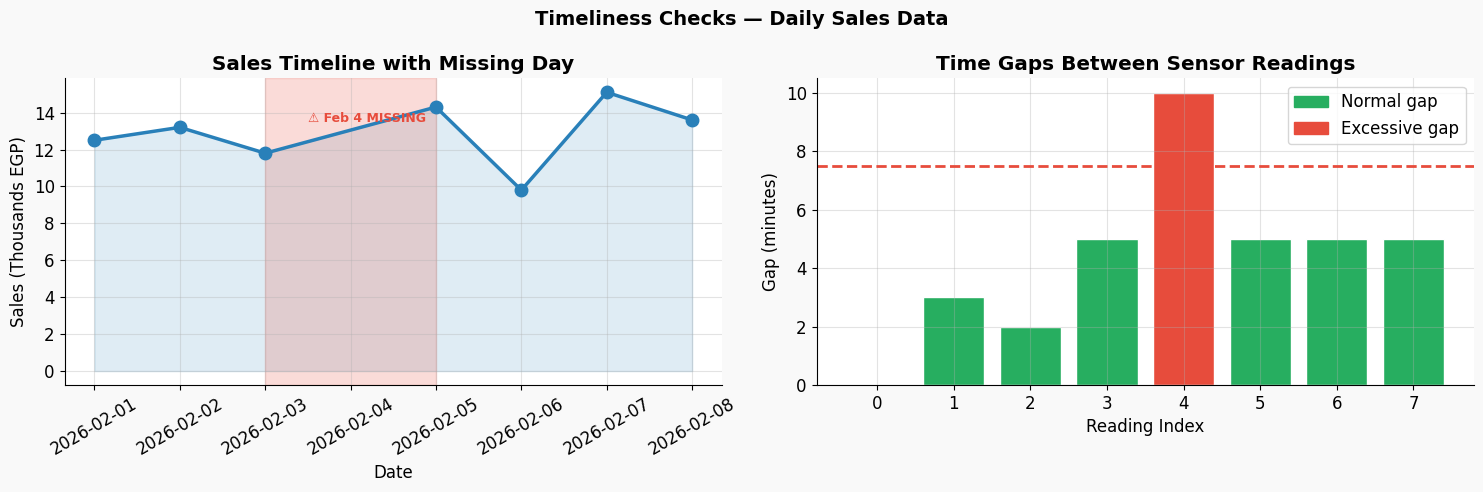


💡 KEY INSIGHT: Missing days in sales data could mean system downtime,
   data pipeline failure, or simply a weekend/holiday — each requires
   different handling! Always INVESTIGATE before imputing.


In [13]:
# ── Timeliness Visualization ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("Timeliness Checks — Daily Sales Data", fontsize=14, fontweight='bold')

# Left: Sales timeline with gap annotation
ax = axes[0]
sorted_sales = sales_df.sort_values('date').drop_duplicates('date')
ax.plot(
    sorted_sales['date'],
    sorted_sales['sales_EGP'] / 1000,
    marker='o',
    linewidth=2.5,
    color='#2980b9',
    markersize=9,
    label='Sales',
)
ax.fill_between(
    sorted_sales['date'], sorted_sales['sales_EGP'] / 1000, alpha=0.15, color='#2980b9'
)

# Mark gap
ax.axvspan(
    pd.Timestamp('2026-02-03'), pd.Timestamp('2026-02-05'), alpha=0.2, color='#e74c3c'
)
ax.text(
    pd.Timestamp('2026-02-03 12:00'),
    13.5,
    "⚠️ Feb 4 MISSING",
    color='#e74c3c',
    fontsize=9,
    fontweight='bold',
)

ax.set_title("Sales Timeline with Missing Day", fontweight='bold')
ax.set_ylabel("Sales (Thousands EGP)")
ax.set_xlabel("Date")
ax.tick_params(axis='x', rotation=30)

# Right: Sensor gap chart
ax2 = axes[1]
sensor_sorted = sensor_readings.sort_values('timestamp').reset_index(drop=True)
sensor_sorted['time_gap_min'] = (
    sensor_sorted['timestamp'].diff().dt.total_seconds() / 60
)

gap_colors = [
    '#e74c3c' if (g and g > 7) else '#27ae60' for g in sensor_sorted['time_gap_min']
]

ax2.bar(
    range(len(sensor_sorted)),
    sensor_sorted['time_gap_min'].fillna(0),
    color=gap_colors,
    edgecolor='white',
)
ax2.axhline(
    y=7.5,
    color='#e74c3c',
    linestyle='--',
    linewidth=2,
    label='Max acceptable gap (7.5 min)',
)
ax2.set_title("Time Gaps Between Sensor Readings", fontweight='bold')
ax2.set_ylabel("Gap (minutes)")
ax2.set_xlabel("Reading Index")
ax2.legend()

green_p = mpatches.Patch(color='#27ae60', label='Normal gap')
red_p = mpatches.Patch(color='#e74c3c', label='Excessive gap')
ax2.legend(handles=[green_p, red_p])

plt.tight_layout()
plt.show()
print("\n💡 KEY INSIGHT: Missing days in sales data could mean system downtime,")
print("   data pipeline failure, or simply a weekend/holiday — each requires")
print("   different handling! Always INVESTIGATE before imputing.")


---
<div style="background: linear-gradient(90deg, #f39c12 0%, #d68910 100%); padding: 18px 28px; border-radius: 10px;">
  <h1 style="color: white; margin: 0; font-size: 2em;">📊 Dimension 7 — Distribution Profile</h1>
</div>

### What is a Distribution Profile?

A **distribution profile** examines how values are **spread** within a column. It helps you understand:
- What's the typical value? (central tendency)
- How spread out are the values? (dispersion)
- Is the distribution symmetric or skewed?
- Are there unusually heavy tails?

### Key Statistics

| Statistic | Formula / Function | What it tells you |
|---|---|---|
| **Mean** | $\bar{x} = \frac{\sum x_i}{n}$ | Arithmetic average (sensitive to outliers) |
| **Median** | Middle value when sorted | Robust center (not affected by outliers) |
| **Std (σ)** | $\sigma = \sqrt{\frac{\sum(x-\bar{x})^2}{n}}$ | Average spread from the mean |
| **Min / Max** | — | Range of values |
| **Skewness** | `scipy.stats.skew()` | Symmetry of distribution |
| **Kurtosis** | `scipy.stats.kurtosis()` | Peakedness vs. normal distribution |



---
## 📐 Skewness — Measuring Asymmetry

$$\text{Skewness} = \frac{1}{n} \sum \left( \frac{x_i - \bar{x}}{\sigma} \right)^3$$

NOTE: Cubing is important because it preserves the sign.

**Interpretation:**

- 0 → symmetric
- \> 0 → right-skewed (long tail to the right)
- < 0 → left-skewed (long tail to the left)

### Three Types of Skewness

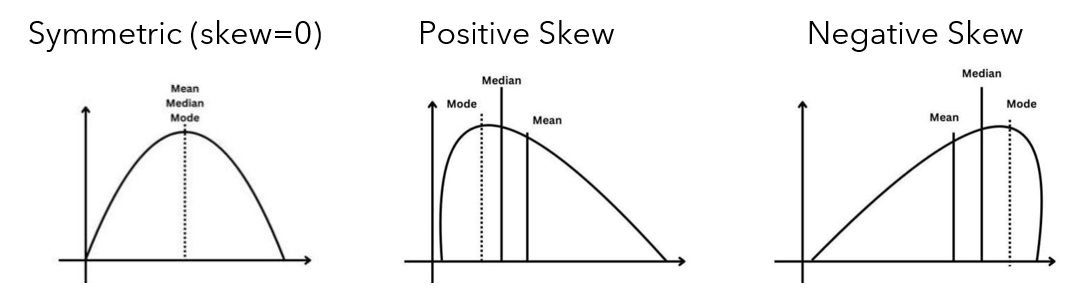

```
SYMMETRIC (skew ≈ 0)                   POSITIVE SKEW (skew > 0)             NEGATIVE SKEW (skew < 0)
─────────────                          ────────────────                     ────────────────
Mean=Median=Mode                       Mode < Median < Mean                 Mean < Median < Mode
                                        (tail → right)                        (tail → left)
```

> **Key intuition**: the mean is the most sensitive to outliers — it always gets pulled toward the tail, dragging it away from the mode. The median resists this pull, sitting between them.

- **Mode** — the value that appears **most frequently**. It's the peak of the density curve — where most data is concentrated.
- **Mean** — the arithmetic average. It is the **balance point of the distribution**. It is **sensitive to outliers**. gets **pulled** toward the long **tail**. Even a few very large values (e.g. billionaires in income data) exert enormous leverage on the average. A single value of 1,000,000 can shift the mean dramatically.
- **Median** — the **middle value** when data is sorted. Exactly 50% of data falls below it, 50% above. It is **resistant to outliers**. It only cares about the **middle position** in sorted data — not how far extreme values are.


> **One sentence**: the mean chases the tail because outliers move the balance point; the median ignores how far they are; the mode just stays at the peak.


| Skewness Value | Classification |
|---|---|
| `< -1` | Strongly negatively skewed |
| `-1 to -0.5` | Moderately negatively skewed |
| `-0.5 to 0.5` | **Approximately symmetric** ✅ |
| `0.5 to 1` | Moderately positively skewed |
| `> 1` | Strongly positively skewed |



### `scipy.stats.skew()` Parameters

```python
scipy.stats.skew(a, axis=0, bias=True, nan_policy='propagate')
```

| Parameter | Options | Meaning |
|---|---|---|
| `a` | array-like | Input data |
| `axis` | int or None | Axis along which to compute |
| `bias` | `True` / `False` | If False, corrects for statistical bias |
| `nan_policy` | `'propagate'`, `'raise'`, `'omit'` | NaN handling |


---
## 📊 Central Tendency — Mean, Median, Mode

---

### 📌 Median
> Median is **quantile(0.50)** — the following are all equivalent:
```python
df.median()
df['col'].quantile(0.50)
df['col'].median()
```

---

### 📌 Quantiles
> General quantile calculation:
```python
df.quantile(0.5)
df.quantile([0, 0.25, 0.50, 0.75, 1.0])
df['col'].quantile(0.5)
df['col'].quantile([0, 0.25, 0.50, 0.75, 1.0])
```

---

### 📌 Mean
> Mean is the **arithmetic average** — sensitive to outliers:
```python
df.mean()
df['col'].mean()
```

---

### 📌 Mode
> Mode is the **most frequent value** — use `iloc[0]` in case of multiple modes:
```python
df.mode().iloc[0]       # first mode of each column
df['col'].mode()[0]     # first mode of a single column
```
---

In [14]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# EXAMPLE: Three columns with symmetric, positive, and negative skew
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
print("=" * 70)
print("Skewness Demonstration — Three Designed Distributions")
print("=" * 70)

dist_df = pd.DataFrame(
    {
        # Symmetric: exam scores centered around 75
        'exam_scores': [
            55,
            60,
            62,
            65,
            67,
            68,
            70,
            72,
            73,
            75,
            75,
            77,
            78,
            80,
            82,
            83,
            85,
            87,
            88,
            90,
        ],
        # Positive skew: wealth (most people earn little, few earn a lot)
        'wealth_kEGP': [
            20,
            22,
            25,
            25,
            27,
            28,
            30,
            31,
            32,
            33,
            35,
            38,
            40,
            45,
            50,
            60,
            80,
            120,
            200,
            500,
        ],
        # Negative skew: retirement age (most retire normally, few retire very early)
        'retirement_age': [
            38,
            42,
            52,
            55,
            57,
            58,
            59,
            60,
            61,
            62,
            62,
            63,
            63,
            64,
            64,
            65,
            65,
            65,
            65,
            65,
        ],
    }
)

print("\n📋 Descriptive Statistics:")
desc = dist_df.describe().round(2)
# To add mode into describe() style output:
desc.loc['mode'] = dist_df.mode().iloc[0]
print(desc)

# To make 1 df containing mean, median, mode:
stats_df = pd.DataFrame(
    {
        'mean': dist_df.mean(),
        'median': dist_df.median(),
        'mode': dist_df.mode().iloc[0],
        'Q1': dist_df.quantile(0.25),
        'Q2': dist_df.quantile(0.5),
        'Q3': dist_df.quantile(0.75),
    }
)
print(stats_df)

print("\n📊 Skewness Values:")
for col in dist_df.columns:
    s = skew(dist_df[col])
    tag = (
        "≈ Symmetric"
        if abs(s) < 0.5
        else ("Positive Skew (right tail)" if s > 0 else "Negative Skew (left tail)")
    )
    print(f"   {col:20s}: skewness = {s:+.3f}  →  {tag}")

Skewness Demonstration — Three Designed Distributions

📋 Descriptive Statistics:
       exam_scores  wealth_kEGP  retirement_age
count        20.00        20.00           20.00
mean         74.60        72.05           59.25
std           9.82       109.30            7.55
min          55.00        20.00           38.00
25%          67.75        27.75           57.75
50%          75.00        34.00           62.00
75%          82.25        52.50           64.25
max          90.00       500.00           65.00
mode         75.00        25.00           65.00
                 mean  median  mode     Q1    Q2     Q3
exam_scores     74.60    75.0    75  67.75  75.0  82.25
wealth_kEGP     72.05    34.0    25  27.75  34.0  52.50
retirement_age  59.25    62.0    65  57.75  62.0  64.25

📊 Skewness Values:
   exam_scores         : skewness = -0.233  →  ≈ Symmetric
   wealth_kEGP         : skewness = +3.288  →  Positive Skew (right tail)
   retirement_age      : skewness = -1.740  →  Negative Skew (

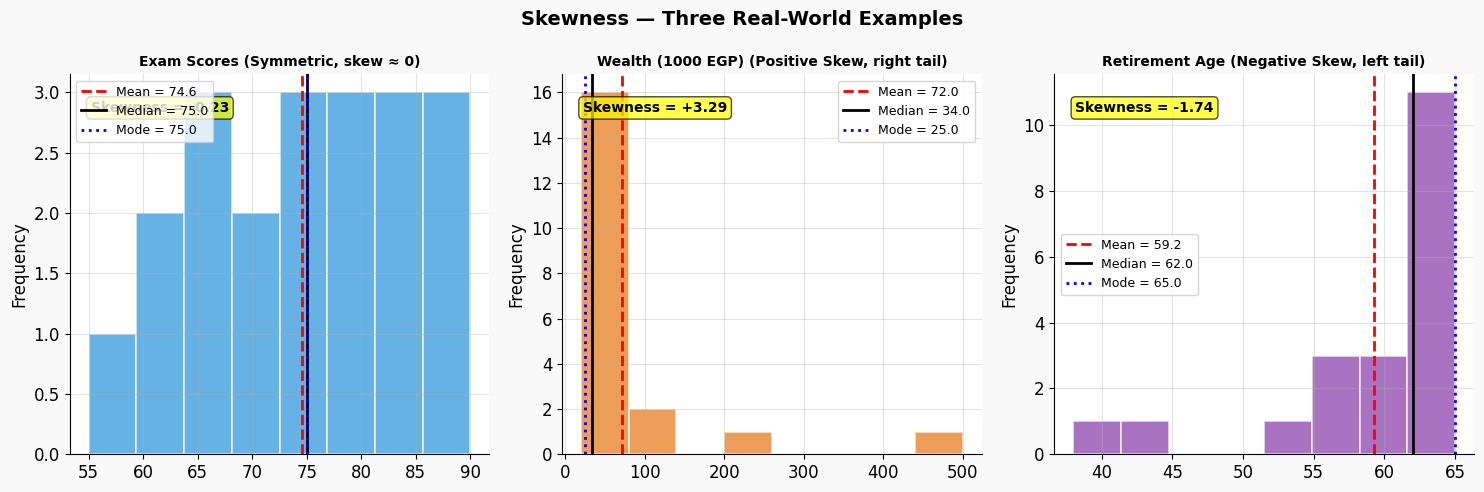


💡 KEY INSIGHT:
   • When Mean ≈ Median ≈ Mode → roughly symmetric
   • When Mean > Median > Mode → positive skew (long right tail)
   • When Mean < Median < Mode → negative skew (long left tail)


In [15]:
# ── Skewness Visualization ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Skewness — Three Real-World Examples", fontsize=14, fontweight='bold')

configs = [
    ('exam_scores', '#3498db', 'Exam Scores (Symmetric, skew ≈ 0)'),
    ('wealth_kEGP', '#e67e22', 'Wealth (1000 EGP) (Positive Skew, right tail)'),
    ('retirement_age', '#8e44ad', 'Retirement Age (Negative Skew, left tail)'),
]

for ax, (col, color, title) in zip(axes, configs):
    data = dist_df[col]
    s = skew(data)
    mean = data.mean()
    med = data.median()
    mode = data.mode()[0]

    ax.hist(data, bins=8, color=color, alpha=0.75, edgecolor='white', linewidth=1.2)
    ax.axvline(
        mean, color='red', linestyle='--', linewidth=2, label=f'Mean = {mean:.1f}'
    )
    ax.axvline(
        med, color='black', linestyle='-', linewidth=2, label=f'Median = {med:.1f}'
    )
    ax.axvline(
        mode, color='blue', linestyle=':', linewidth=2, label=f'Mode = {mode:.1f}'
    )
    ax.set_title(title, fontweight='bold', fontsize=10)
    ax.set_ylabel("Frequency")
    ax.legend(fontsize=9)

    # Annotation
    bbox = dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7)
    ax.text(
        0.05,
        0.93,
        f'Skewness = {s:+.2f}',
        transform=ax.transAxes,
        fontsize=10,
        fontweight='bold',
        bbox=bbox,
        va='top',
    )

plt.tight_layout()
plt.show()
print("\n💡 KEY INSIGHT:")
print("   • When Mean ≈ Median ≈ Mode → roughly symmetric")
print("   • When Mean > Median > Mode → positive skew (long right tail)")
print("   • When Mean < Median < Mode → negative skew (long left tail)")


---
## 🏔️ Kurtosis — Measuring Peakedness

$$\text{Kurtosis} = \frac{1}{n} \sum \left( \frac{x_i - \bar{x}}{\sigma} \right)^4 - 3$$

> The **-3** term is the "excess kurtosis" correction, making the normal distribution have kurtosis = 0.

### Three Types of Kurtosis

| Type | Kurtosis Value | Shape | Example |
|---|---|---|---|
| **Mesokurtic** | ≈ 0 | Normal bell curve | IQ scores |
| **Leptokurtic** | **> 0** | Taller peak, **heavier tails** | Stock returns (fat tails = more crashes) |
| **Platykurtic** | **< 0** | Flatter, shorter peak | Uniform distribution |

### `scipy.stats.kurtosis()` Parameters

```python
scipy.stats.kurtosis(a, axis=0, fisher=True, bias=True, nan_policy='propagate')
```

| Parameter | Options | Meaning |
|---|---|---|
| `fisher` | `True` (default) | Returns **excess kurtosis** (normal = 0) |
| `fisher` | `False` | Returns **Pearson kurtosis** (normal = 3) |
| `bias` | `True` / `False` | Statistical bias correction |

> ⚠️ `scipy` and `pandas` use **excess kurtosis** by default (normal = 0). Some textbooks report Pearson kurtosis (normal = 3). Know which one you're using!


In [16]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# EXAMPLE: Kurtosis — Three designed distributions
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
print("=" * 70)
print("Kurtosis Demonstration")
print("=" * 70)

kurt_df = pd.DataFrame(
    {
        # Mesokurtic: roughly normal
        'iq_scores': [
            80,
            85,
            90,
            93,
            96,
            98,
            99,
            100,
            100,
            101,
            101,
            102,
            104,
            106,
            109,
            112,
            115,
            118,
            122,
            128,
        ],
        # Leptokurtic: clustered tightly in center with extreme tails
        'stock_returns_pct': [
            -15,
            -8,
            -1,
            -0.5,
            -0.3,
            0,
            0,
            0.2,
            0.3,
            0.5,
            0.5,
            0.6,
            0.7,
            0.8,
            1.0,
            1.2,
            2.0,
            5.0,
            9.0,
            18.0,
        ],
        # Platykurtic: spread evenly, no pronounced peak
        'dice_sums': [2, 3, 4, 5, 5, 6, 6, 7, 7, 7, 8, 8, 9, 9, 10, 10, 11, 11, 12, 12],
    }
)

print("\n📊 Kurtosis Values (excess, normal=0):")
for col in kurt_df.columns:
    k = kurtosis(kurt_df[col])
    s = skew(kurt_df[col])
    tag = (
        "Mesokurtic (≈ normal)"
        if abs(k) < 0.5
        else ("Leptokurtic (heavy tails)" if k > 0 else "Platykurtic (light tails)")
    )
    print(f"   {col:22s}: kurtosis = {k:+.3f}  →  {tag}  (skew={s:+.2f})")

Kurtosis Demonstration

📊 Kurtosis Values (excess, normal=0):
   iq_scores             : kurtosis = -0.222  →  Mesokurtic (≈ normal)  (skew=+0.23)
   stock_returns_pct     : kurtosis = +3.249  →  Leptokurtic (heavy tails)  (skew=+0.28)
   dice_sums             : kurtosis = -0.891  →  Platykurtic (light tails)  (skew=-0.18)


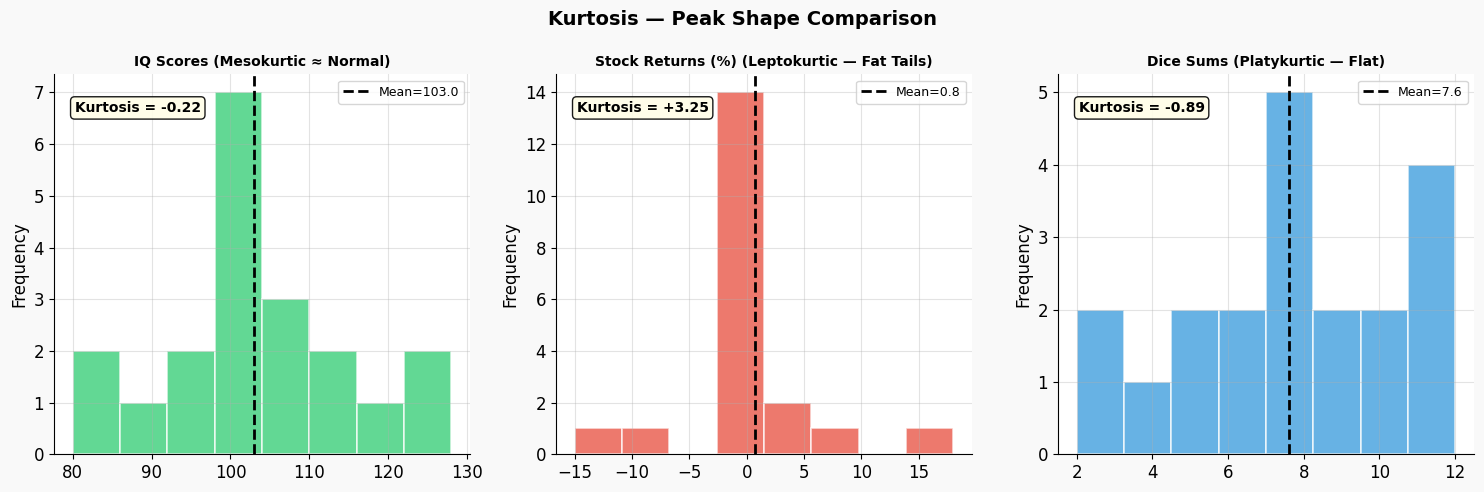


💡 KEY INSIGHT for Data Validation:
   • High positive kurtosis (leptokurtic) → MORE extreme values than expected
     → More likely to have severe outliers
   • Negative kurtosis (platykurtic) → Values more spread evenly
     → Fewer extreme outliers but wider range


In [17]:
# ── Kurtosis Visualization ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Kurtosis — Peak Shape Comparison", fontsize=14, fontweight='bold')

kurt_configs = [
    ('iq_scores', '#2ecc71', 'IQ Scores (Mesokurtic ≈ Normal)'),
    ('stock_returns_pct', '#e74c3c', 'Stock Returns (%) (Leptokurtic — Fat Tails)'),
    ('dice_sums', '#3498db', 'Dice Sums (Platykurtic — Flat)'),
]

for ax, (col, color, title) in zip(axes, kurt_configs):
    data = kurt_df[col]
    k = kurtosis(data)
    ax.hist(data, bins=8, color=color, alpha=0.75, edgecolor='white', linewidth=1.2)
    ax.axvline(
        data.mean(),
        color='black',
        linestyle='--',
        linewidth=2,
        label=f'Mean={data.mean():.1f}',
    )
    ax.set_title(title, fontweight='bold', fontsize=10)
    ax.set_ylabel("Frequency")
    ax.legend(fontsize=9)

    bbox = dict(boxstyle='round,pad=0.3', facecolor='#fffde7', alpha=0.9)
    ax.text(
        0.05,
        0.93,
        f'Kurtosis = {k:+.2f}',
        transform=ax.transAxes,
        fontsize=10,
        fontweight='bold',
        bbox=bbox,
        va='top',
    )

plt.tight_layout()
plt.show()
print("\n💡 KEY INSIGHT for Data Validation:")
print("   • High positive kurtosis (leptokurtic) → MORE extreme values than expected")
print("     → More likely to have severe outliers")
print("   • Negative kurtosis (platykurtic) → Values more spread evenly")
print("     → Fewer extreme outliers but wider range")


---
## 📏 Kolmogorov-Smirnov (KS) Test — Distribution Comparison

The **KS test** checks if a dataset follows a specific distribution (one-sample) or if two datasets come from the same distribution (two-sample).

### Use Case in Data Validation

> 🚨 **Data Drift Detection:** Has your production data drifted away from the training distribution? If yes, your model may no longer be valid!

### How It Works

The KS test compares the **Empirical Cumulative Distribution Function (ECDF)** of your data against a reference distribution.

```
ECDF: F_n(x) = (number of observations ≤ x) / n
KS statistic: D = max|F_n(x) - F(x)|
```

| KS Statistic | Meaning |
|---|---|
| `≈ 0` | Distributions are nearly identical ✅ |
| `0.05–0.15` | Small difference |
| `> 0.2` | Significant difference ⚠️ |
| `→ 1` | Completely different distributions 🚨 |

### `scipy.stats.kstest()` Parameters

```python
kstest(rvs, cdf, args=(), N=20, alternative='two-sided', method='auto')
```

| Parameter | Meaning |
|---|---|
| `rvs` | Your observed data (array) |
| `cdf` | Distribution name (e.g., `'norm'`, `'expon'`) or callable |
| `args` | Parameters for the reference distribution: `(mean, std)` for normal |
| `alternative` | `'two-sided'` (default), `'less'`, `'greater'` |

**Returns:**
- `statistic` — KS distance (0 to 1)
- `pvalue` — If < 0.05, reject H₀ (data does NOT follow the distribution)


In [18]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# EXAMPLE 1: Exam scores — near-normal → KS should PASS (high p-value)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
print("=" * 65)
print("EXAMPLE 1 — Near-Normal Exam Scores → KS test should PASS")
print("=" * 65)

exam_scores = np.array(
    [58, 62, 65, 67, 69, 70, 71, 72, 73, 74, 75, 75, 76, 77, 78, 79, 80, 82, 83, 85]
)

ks_stat, p_val = kstest(
    exam_scores, 'norm', args=(np.mean(exam_scores), np.std(exam_scores))
)

print(f"\nData   : {exam_scores}")
print(f"Mean   : {np.mean(exam_scores):.2f}  |  Std: {np.std(exam_scores):.2f}")
print(f"\nKS Statistic : {ks_stat:.4f}  (closer to 0 = more normal)")
print(f"p-value       : {p_val:.4f}")
print()
if p_val > 0.05:
    print("✅ RESULT: Not Reject H₀ → Data is consistent with Normal distribution")
else:
    print("⚠️  RESULT: Reject H₀ → Data significantly differs from Normal distribution")

EXAMPLE 1 — Near-Normal Exam Scores → KS test should PASS

Data   : [58 62 65 67 69 70 71 72 73 74 75 75 76 77 78 79 80 82 83 85]
Mean   : 73.55  |  Std: 6.85

KS Statistic : 0.0838  (closer to 0 = more normal)
p-value       : 0.9967

✅ RESULT: Not Reject H₀ → Data is consistent with Normal distribution


In [19]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# EXAMPLE 2: Corrupted scores with extreme outliers → KS should FAIL
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
print("=" * 65)
print("EXAMPLE 2 — Corrupted Scores (extreme outliers) → KS test FAILS")
print("=" * 65)

corrupted_scores = np.array(
    [58, 62, 65, 67, 69, 70, 71, 72, 73, 74, 75, 75, 76, 77, 78, 79, 80, 82, -200, 300]
)
#                                                                ^^^^  ^^^  corrupted

ks2, p2 = kstest(
    corrupted_scores, 'norm', args=(np.mean(corrupted_scores), np.std(corrupted_scores))
)

print(f"\nData   : {corrupted_scores}")
print(
    f"Mean   : {np.mean(corrupted_scores):.2f}  |  Std: {np.std(corrupted_scores):.2f}  ← pulled by outliers!"
)
print(f"\nKS Statistic : {ks2:.4f}  (larger = more deviation)")
print(f"p-value       : {p2:.6f}")
print()
if p2 > 0.05:
    print("✅ RESULT: Not reject H₀")
else:
    print("🚨 RESULT: Reject H₀ → Data does NOT follow Normal distribution!")
    print("   → Investigate the extreme values (-200, 300) — likely data entry errors!")

EXAMPLE 2 — Corrupted Scores (extreme outliers) → KS test FAILS

Data   : [  58   62   65   67   69   70   71   72   73   74   75   75   76   77
   78   79   80   82 -200  300]
Mean   : 70.15  |  Std: 79.56  ← pulled by outliers!

KS Statistic : 0.3908  (larger = more deviation)
p-value       : 0.002910

🚨 RESULT: Reject H₀ → Data does NOT follow Normal distribution!
   → Investigate the extreme values (-200, 300) — likely data entry errors!


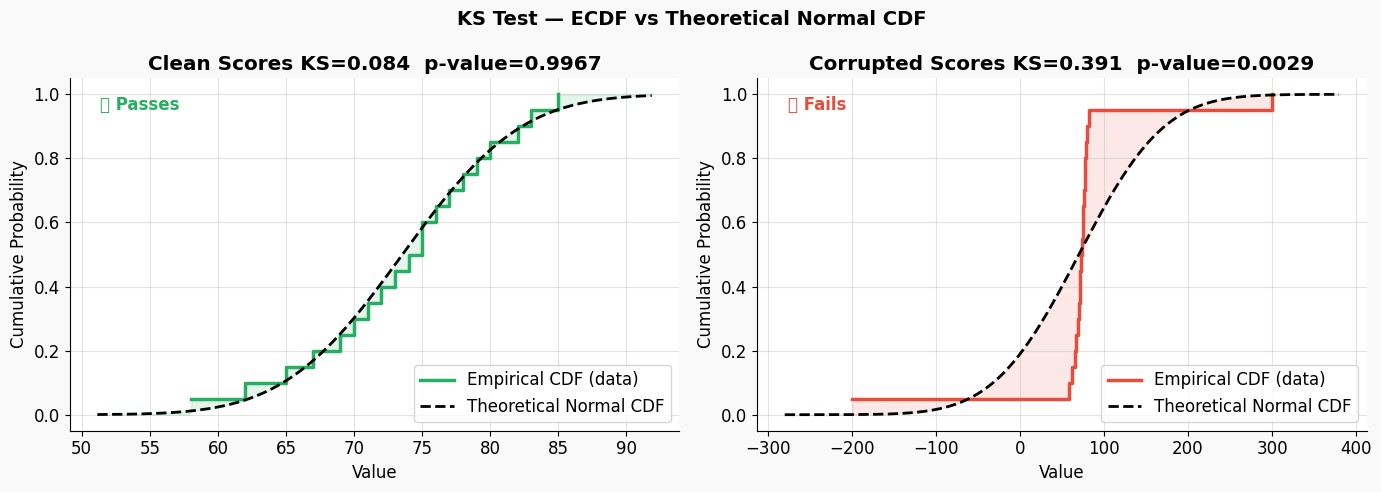


💡 The KS DISTANCE is the maximum vertical gap between the two CDF curves.
   Larger gaps → more evidence the data does NOT follow the expected distribution.


In [20]:
# ── KS Test Visualization (ECDF vs Theoretical CDF) ──────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("KS Test — ECDF vs Theoretical Normal CDF", fontsize=14, fontweight='bold')

for ax, (data, label, ks, pv, color) in zip(
    axes,
    [
        (exam_scores, "Clean Scores", ks_stat, p_val, '#27ae60'),
        (corrupted_scores, "Corrupted Scores", ks2, p2, '#e74c3c'),
    ],
):
    mu, sigma = np.mean(data), np.std(data)

    # Empirical CDF
    sorted_data = np.sort(data)
    ecdf = np.arange(1, len(sorted_data) + 1) / len(sorted_data)

    # Theoretical CDF
    x_range = np.linspace(sorted_data.min() - sigma, sorted_data.max() + sigma, 300)
    theoretical_cdf = stats.norm.cdf(x_range, mu, sigma)

    ax.step(
        sorted_data,
        ecdf,
        where='post',
        color=color,
        linewidth=2.5,
        label='Empirical CDF (data)',
    )
    ax.plot(
        x_range, theoretical_cdf, 'k--', linewidth=2, label='Theoretical Normal CDF'
    )

    ax.fill_between(
        x_range,
        [np.searchsorted(sorted_data, x, 'right') / len(sorted_data) for x in x_range],
        theoretical_cdf,
        alpha=0.12,
        color=color,
    )

    ax.set_title(f"{label} KS={ks:.3f}  p-value={pv:.4f}", fontweight='bold')
    ax.set_xlabel("Value")
    ax.set_ylabel("Cumulative Probability")
    ax.legend()

    result = "✅ Passes" if pv > 0.05 else "🚨 Fails"
    ax.text(
        0.05,
        0.95,
        result,
        transform=ax.transAxes,
        fontsize=12,
        fontweight='bold',
        color='#27ae60' if pv > 0.05 else '#e74c3c',
        va='top',
    )

plt.tight_layout()
plt.show()
print("\n💡 The KS DISTANCE is the maximum vertical gap between the two CDF curves.")
print(
    "   Larger gaps → more evidence the data does NOT follow the expected distribution."
)


---
<div style="background: linear-gradient(90deg, #6c3483 0%, #4a235a 100%); padding: 18px 28px; border-radius: 10px;">
  <h1 style="color: white; margin: 0; font-size: 2em;">🔗 Dimension 8 — Relationships & Correlation</h1>
</div>

### Why Validate Relationships?

Examining **correlations and dependencies** between fields helps uncover:

- 🚨 **Data quality issues:** Two fields that should be independent are correlated
- 🚨 **Multicollinearity:** Highly correlated features that destabilize models
- ✅ **Expected patterns:** Customer ID correlating with purchase amount → IDs not randomly assigned
- ✅ **Implied relationships:** ZIP code → City, State (affects normalization)

### Two Main Methods

| Method | Type | Assumption | Best For |
|---|---|---|---|
| **Pearson** | Linear | Data is normally distributed | Continuous numerical data |
| **Spearman** | Monotonic | No distributional assumption | Ordinal / non-normal / outliers present |



---
## 📐 Method 1: Pearson Correlation

$$r = \frac{\text{Cov}(X, Y)}{\sigma_X \cdot \sigma_Y} = \frac{\sum(x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum(x_i-\bar{x})^2 \cdot \sum(y_i-\bar{y})^2}}$$

### Interpretation

| r Value | Strength | Direction |
|---|---|---|
| `+1.0` | Perfect | Positive (as X↑, Y↑) |
| `+0.7 to +1.0` | Strong Positive | — |
| `+0.4 to +0.7` | Moderate Positive | — |
| `+0.1 to +0.4` | Weak Positive | — |
| `0` | No linear relationship | — |
| `-0.1 to -0.4` | Weak Negative | — |
| `-0.4 to -0.7` | Moderate Negative | — |
| `-0.7 to -1.0` | Strong Negative | — |
| `-1.0` | Perfect | Negative (as X↑, Y↓) |

### `df.corr()` Parameters

```python
df.corr(method='pearson', min_periods=1, numeric_only=False)
```

| Parameter | Options | Meaning |
|---|---|---|
| `method` | `'pearson'`, `'spearman'`, `'kendall'` | Correlation method |
| `min_periods` | int | Min non-null pairs required per column pair |
| `numeric_only` | `True` / `False` | Include only numeric columns |

**Output:** A symmetric DataFrame where `result.loc[col1, col2]` = correlation between col1 and col2.


In [21]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# EXAMPLE 1: Strong, Weak, and Negative Pearson Correlation
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
print("=" * 70)
print("EXAMPLE 1 — Pearson Correlation: 4 relationship types")
print("=" * 70)

corr_df = pd.DataFrame(
    {
        'study_hours': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
        'exam_score': [48, 55, 60, 65, 72, 75, 80, 85, 90, 95],  # strong positive
        'sleep_hours': [9, 8, 8, 7, 7, 6, 6, 5, 5, 4],  # negative
        'shoe_size': [40, 42, 41, 43, 42, 44, 41, 43, 42, 44],  # no relationship
        'hours_squared': [
            1,
            4,
            9,
            16,
            25,
            36,
            49,
            64,
            81,
            100,
        ],  # same as study (perfect linear)
    }
)

pearson_matrix = corr_df.corr(method='pearson').round(3)
print("\n📋 Pearson Correlation Matrix:")
print(pearson_matrix)

print("\n📊 Key Correlations with exam_score:")
for col in ['study_hours', 'sleep_hours', 'shoe_size', 'hours_squared']:
    r = pearson_matrix.loc['exam_score', col]
    print(f"   exam_score vs {col:15s}: r = {r:+.3f}")

EXAMPLE 1 — Pearson Correlation: 4 relationship types

📋 Pearson Correlation Matrix:
               study_hours  exam_score  sleep_hours  shoe_size  hours_squared
study_hours          1.000       0.998       -0.986      0.585          0.975
exam_score           0.998       1.000       -0.984      0.595          0.965
sleep_hours         -0.986      -0.984        1.000     -0.694         -0.961
shoe_size            0.585       0.595       -0.694      1.000          0.531
hours_squared        0.975       0.965       -0.961      0.531          1.000

📊 Key Correlations with exam_score:
   exam_score vs study_hours    : r = +0.998
   exam_score vs sleep_hours    : r = -0.984
   exam_score vs shoe_size      : r = +0.595
   exam_score vs hours_squared  : r = +0.965


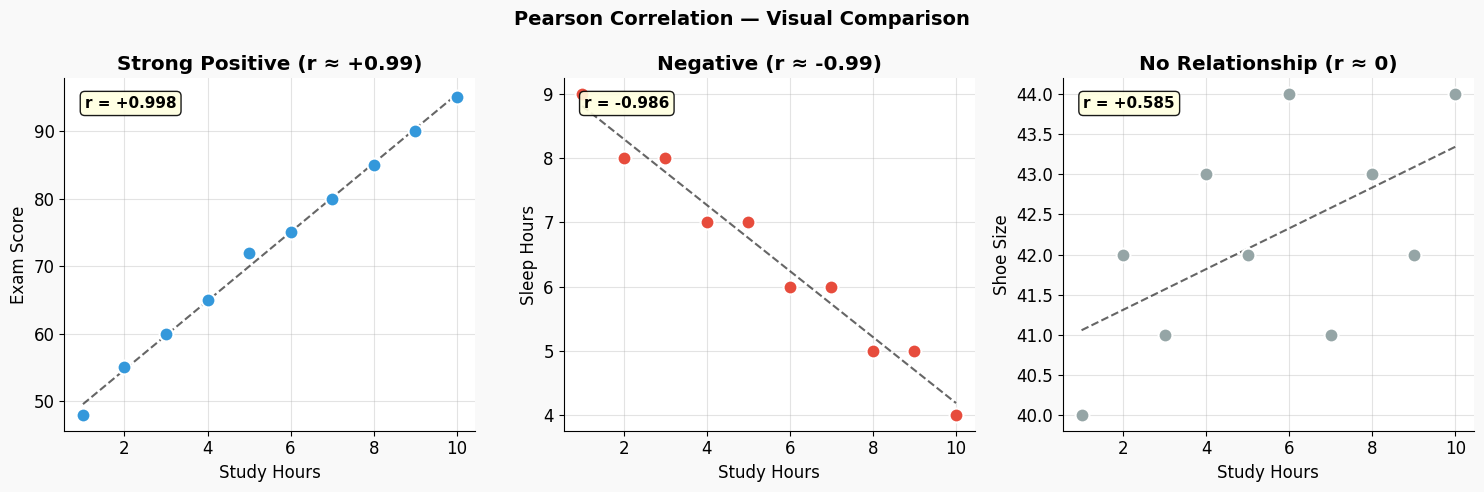


💡 KEY INSIGHT: Pearson ONLY captures LINEAR relationships.
   A curved relationship may have r ≈ 0 even if the two variables are strongly related!


In [22]:
# ── Scatter Plots Showing Different Correlation Types ─────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Pearson Correlation — Visual Comparison", fontsize=14, fontweight='bold')

scatter_configs = [
    ('study_hours', 'exam_score', '#3498db', 'Strong Positive (r ≈ +0.99)'),
    ('study_hours', 'sleep_hours', '#e74c3c', 'Negative (r ≈ -0.99)'),
    ('study_hours', 'shoe_size', '#95a5a6', 'No Relationship (r ≈ 0)'),
]

for ax, (x_col, y_col, color, title) in zip(axes, scatter_configs):
    r = corr_df[[x_col, y_col]].corr().iloc[0, 1]
    ax.scatter(
        corr_df[x_col],
        corr_df[y_col],
        c=color,
        s=100,
        edgecolors='white',
        linewidth=1.5,
        zorder=3,
    )

    # Trend line
    m, b = np.polyfit(corr_df[x_col], corr_df[y_col], 1)
    x_line = np.linspace(corr_df[x_col].min(), corr_df[x_col].max(), 100)
    ax.plot(x_line, m * x_line + b, '--', color='black', alpha=0.6, linewidth=1.5)

    ax.set_title(title, fontweight='bold')
    ax.set_xlabel(x_col.replace('_', ' ').title())
    ax.set_ylabel(y_col.replace('_', ' ').title())

    bbox = dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.9)
    ax.text(
        0.05,
        0.95,
        f'r = {r:+.3f}',
        transform=ax.transAxes,
        fontsize=11,
        fontweight='bold',
        bbox=bbox,
        va='top',
    )

plt.tight_layout()
plt.show()
print("\n💡 KEY INSIGHT: Pearson ONLY captures LINEAR relationships.")
print(
    "   A curved relationship may have r ≈ 0 even if the two variables are strongly related!"
)


---
## 📐 Method 2: Spearman's Rank Correlation

Spearman converts values to **ranks** and **then computes Pearson correlation on those ranks**.

### Step-by-Step Example

| Student | Hours Studied | Exam Score | Rank (Hours) | Rank (Score) |
|---|---|---|---|---|
| A | 2 | 60 | 1 | 1 |
| B | 4 | 85 | 2 | 2 |
| C | 6 | 90 | 3 | 3 |
| D | 8 | 92 | 4 | 4 |
| E | 10 | 93 | 5 | 5 |

> Notice: As hours go up, rank goes up consistently → **monotonic relationship** → Spearman = 1.0

### Key Advantages Over Pearson

| Situation | Pearson | Spearman |
|---|---|---|
| Outliers present | ❌ Distorted | ✅ Robust |
| Non-linear but monotonic | ❌ Underestimates | ✅ Captures it |
| Ordinal data (rankings) | ❌ Not appropriate | ✅ Correct |
| Normal distribution | ✅ More powerful | ⚠️ Slightly less powerful |

### Monotonic vs Linear

```
LINEAR:    y = 2x + 3        → Both Pearson AND Spearman ≈ 1.0
MONOTONIC: y = x³ (curved)   → Pearson < 1.0, but Spearman ≈ 1.0
NON-MONOTONIC: y = x²        → Both ≈ 0 (non-monotonic around zero)
```


In [23]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# EXAMPLE 1: Linear vs Monotonic (non-linear) — Pearson vs Spearman
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
print("=" * 70)
print("EXAMPLE 1 — Pearson vs Spearman on Linear vs Monotonic Data")
print("=" * 70)

x = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
y_linear = 3 * x + 2  # perfect linear:    y = 3x + 2
y_monotonic = x**3  # monotonic nonlinear: y = x^3
y_with_outlier = np.array([3, 6, 9, 12, 15, 18, 21, 24, 27, 200])  # outlier at end

datasets = [
    ('x', 'y_linear', y_linear, "Linear: y = 3x + 2"),
    ('x', 'y_monotonic', y_monotonic, "Monotonic: y = x³"),
    ('x', 'y_with_outlier', y_with_outlier, "Linear + Outlier"),
]

print(f"\n{'Dataset':<30} {'Pearson r':>12} {'Spearman r':>12}  {'Difference':>10}")
print("-" * 68)
for _, _, y, name in datasets:
    p = np.corrcoef(x, y)[0, 1]
    s = stats.spearmanr(x, y).statistic
    print(
        f"{name:<30} {p:>+12.4f} {s:>+12.4f}  {'← LARGE DIFF!' if abs(p-s) > 0.05 else '≈ same':>10}"
    )

EXAMPLE 1 — Pearson vs Spearman on Linear vs Monotonic Data

Dataset                           Pearson r   Spearman r  Difference
--------------------------------------------------------------------
Linear: y = 3x + 2                  +1.0000      +1.0000      ≈ same
Monotonic: y = x³                   +0.9284      +1.0000  ← LARGE DIFF!
Linear + Outlier                    +0.6297      +1.0000  ← LARGE DIFF!


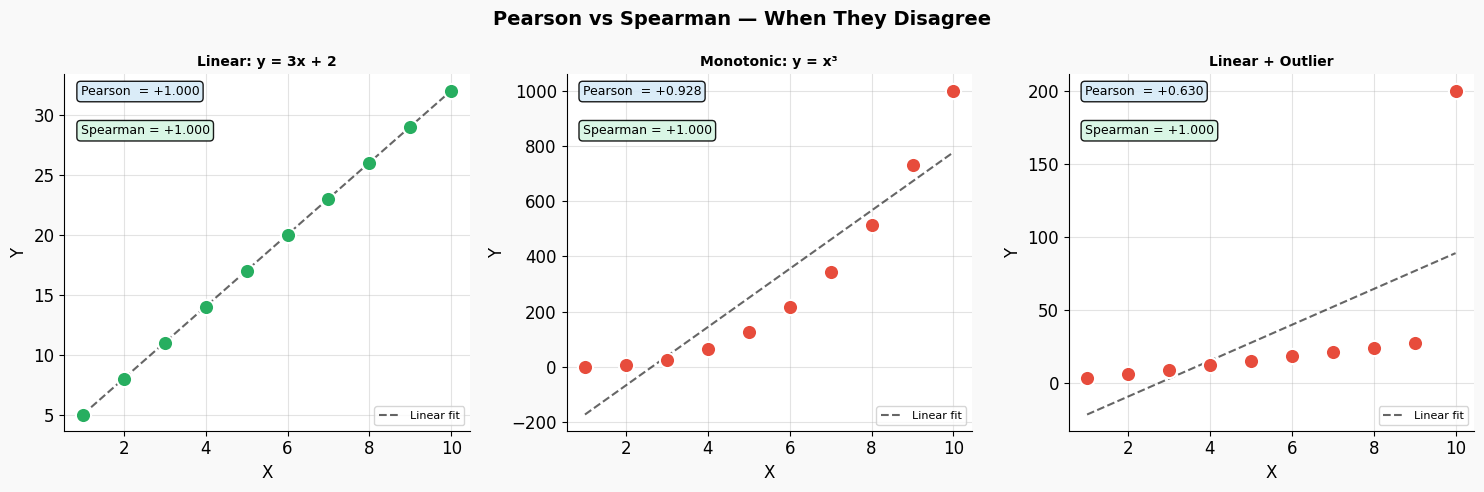


💡 KEY INSIGHTS:
   • Linear:   Pearson ≈ Spearman ≈ 1.0 (both perfect)
   • Monotonic: Spearman = 1.0 but Pearson < 1.0 (misses the nonlinear curve)
   • Outlier:  Pearson is pulled, Spearman stays robust


In [24]:
# ── Visualization: Pearson vs Spearman comparison ─────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Pearson vs Spearman — When They Disagree", fontsize=14, fontweight='bold')

for ax, (_, _, y, name) in zip(axes, datasets):
    p = np.corrcoef(x, y)[0, 1]
    s = stats.spearmanr(x, y).statistic

    color = '#e74c3c' if abs(p - s) > 0.05 else '#27ae60'
    ax.scatter(x, y, c=color, s=120, edgecolors='white', linewidth=1.5, zorder=3)

    # Trend line (Pearson's linear fit)
    m, b = np.polyfit(x, y, 1)
    x_line = np.linspace(x.min(), x.max(), 100)
    ax.plot(x_line, m * x_line + b, 'k--', alpha=0.6, linewidth=1.5, label='Linear fit')

    ax.set_title(name, fontweight='bold', fontsize=10)
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.legend(fontsize=8)

    bbox_p = dict(boxstyle='round', facecolor='#d6eaf8', alpha=0.9)
    bbox_s = dict(boxstyle='round', facecolor='#d5f5e3', alpha=0.9)
    ax.text(
        0.04,
        0.97,
        f'Pearson  = {p:+.3f}',
        transform=ax.transAxes,
        fontsize=9,
        bbox=bbox_p,
        va='top',
    )
    ax.text(
        0.04,
        0.86,
        f'Spearman = {s:+.3f}',
        transform=ax.transAxes,
        fontsize=9,
        bbox=bbox_s,
        va='top',
    )

plt.tight_layout()
plt.show()
print("\n💡 KEY INSIGHTS:")
print("   • Linear:   Pearson ≈ Spearman ≈ 1.0 (both perfect)")
print("   • Monotonic: Spearman = 1.0 but Pearson < 1.0 (misses the nonlinear curve)")
print("   • Outlier:  Pearson is pulled, Spearman stays robust")

In [25]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# EXAMPLE 2: Full Correlation Matrix with Heatmap — Student Dataset
# Replicates the slide's example + more
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
print("=" * 70)
print("EXAMPLE 2 — Correlation Matrix & Heatmap: Multi-Feature Student Data")
print("=" * 70)

multi_df = pd.DataFrame(
    {
        'study_hours': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12],
        'exam_score': [48, 55, 60, 65, 72, 75, 80, 85, 88, 90, 93, 95],
        'absences': [8, 7, 7, 6, 5, 5, 4, 3, 3, 2, 1, 0],
        'sleep_hours': [9, 8, 8, 8, 7, 7, 7, 6, 6, 5, 5, 4],
        'exercise_min': [10, 15, 20, 30, 25, 35, 40, 45, 50, 55, 60, 70],
        'phone_hrs': [6, 5, 5, 5, 4, 4, 3, 3, 2, 2, 1, 1],
    }
)

print("\n📋 Dataset:")
print(multi_df.to_string(index=False))

pearson_m = multi_df.corr(method='pearson').round(3)
spearman_m = multi_df.corr(method='spearman').round(3)

print("\n📊 Pearson Correlation Matrix:")
print(pearson_m)

print("\n📊 Spearman Correlation Matrix:")
print(spearman_m)

# Identify highly correlated pairs (potential data issues)
print("\n🚨 Highly Correlated Pairs (|r| > 0.8) — Multicollinearity Risk:")
seen = set()
for col1 in pearson_m.columns:
    for col2 in pearson_m.columns:
        if col1 != col2 and (col2, col1) not in seen:
            r = pearson_m.loc[col1, col2]
            if abs(r) > 0.8:
                print(f"   {col1:15s} ↔ {col2:15s}: r = {r:+.3f}")
            seen.add((col1, col2))

EXAMPLE 2 — Correlation Matrix & Heatmap: Multi-Feature Student Data

📋 Dataset:
 study_hours  exam_score  absences  sleep_hours  exercise_min  phone_hrs
           1          48         8            9            10          6
           2          55         7            8            15          5
           3          60         7            8            20          5
           4          65         6            8            30          5
           5          72         5            7            25          4
           6          75         5            7            35          4
           7          80         4            7            40          3
           8          85         3            6            45          3
           9          88         3            6            50          2
          10          90         2            5            55          2
          11          93         1            5            60          1
          12          95         0         

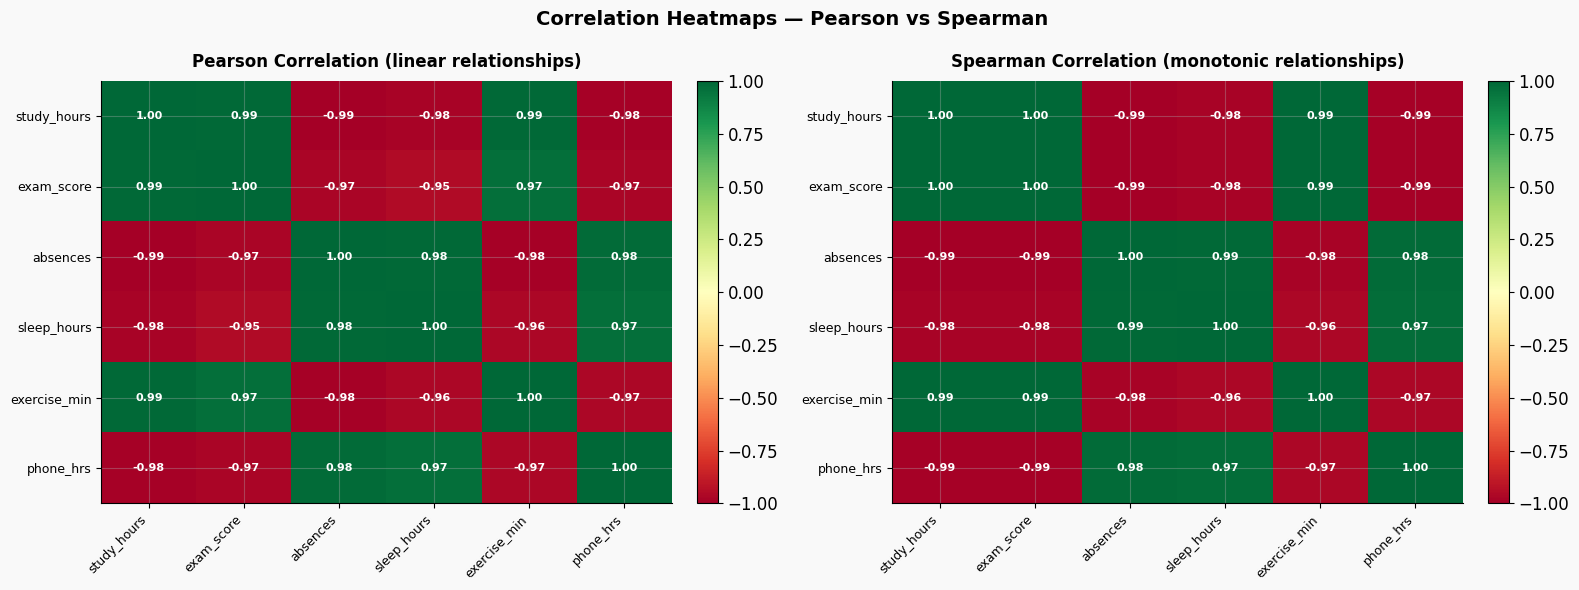


💡 How to read a heatmap:
   🟢 Dark green (close to +1): Strong positive correlation
   🔴 Dark red   (close to -1): Strong negative correlation
   🟡 Yellow     (close to  0): No correlation


In [26]:
# ── Heatmap Visualization ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(
    "Correlation Heatmaps — Pearson vs Spearman", fontsize=14, fontweight='bold'
)


def draw_heatmap(ax, matrix, title):
    cols = matrix.columns.tolist()
    n = len(cols)
    im = ax.imshow(matrix.values, cmap='RdYlGn', vmin=-1, vmax=1, aspect='auto')
    ax.set_xticks(range(n))
    ax.set_yticks(range(n))
    ax.set_xticklabels(cols, rotation=45, ha='right', fontsize=9)
    ax.set_yticklabels(cols, fontsize=9)
    ax.set_title(title, fontweight='bold', fontsize=12, pad=10)

    for i in range(n):
        for j in range(n):
            val = matrix.values[i, j]
            color = 'white' if abs(val) > 0.6 else 'black'
            ax.text(
                j,
                i,
                f'{val:.2f}',
                ha='center',
                va='center',
                fontsize=8,
                fontweight='bold',
                color=color,
            )

    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)


draw_heatmap(axes[0], pearson_m, "Pearson Correlation (linear relationships)")
draw_heatmap(axes[1], spearman_m, "Spearman Correlation (monotonic relationships)")

plt.tight_layout()
plt.show()
print("\n💡 How to read a heatmap:")
print("   🟢 Dark green (close to +1): Strong positive correlation")
print("   🔴 Dark red   (close to -1): Strong negative correlation")
print("   🟡 Yellow     (close to  0): No correlation")


---
## 📊 Data Quality Metrics — Quantification Summary

From the lecture slides — here is the complete scoring table for all 8 dimensions:

| Dimension | What It Measures | Formula |
|---|---|---|
| Accuracy | How closely values match ground truth | `(correct values / total) × 100%` |
| Consistency | Uniformity across systems | `(conforming records / total) × 100%` |
| Completeness | Required data present | `(non-null values / total) × 100%` |
| Uniqueness | Absence of duplicates | `(unique records / total) × 100%` |
| **Outliers** | Proportion of anomalous values | `(non-outlier records / total) × 100%` |
| **Timeliness** | Data freshness and latency | Mean time from event to availability |
| **Distribution** | Current vs expected distribution | KS statistic (0 = identical) |
| **Relationships** | Expected correlations between fields | Pearson or Spearman r |


In [27]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CAPSTONE: Combined Quality Profile on a Single Dataset
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
print("=" * 65)
print("CAPSTONE — Automated Quality Report: Dimensions 5-8")
print("=" * 65)

full_df = pd.DataFrame(
    {
        'student_id': [
            'S01',
            'S02',
            'S03',
            'S04',
            'S05',
            'S06',
            'S07',
            'S08',
            'S09',
            'S10',
            'S11',
            'S12',
            'S13',
            'S14',
            'S15',
        ],
        'timestamp': pd.to_datetime(
            [
                '2026-03-01',
                '2026-03-01',
                '2026-03-02',
                '2026-03-02',
                '2026-03-03',
                '2026-03-03',
                '2026-03-04',
                '2026-03-04',
                '2026-03-05',
                '2026-03-05',
                '2026-03-06',
                '2026-03-06',
                '2026-03-07',
                '2026-03-07',
                '2026-03-08',
            ]
        ),
        'study_hours': [3, 5, 4, 6, 2, 7, 5, 4, 6, 3, 8, 5, 4, 6, 25],  # 25 = outlier
        'exam_score': [60, 72, 65, 80, 55, 85, 73, 68, 82, 58, 90, 74, 67, 79, 40],
        'attendance': [85, 90, 88, 95, 80, 92, 87, 84, 93, 82, 97, 89, 83, 91, 45],
    }
)

print("\n📋 Full Dataset:")
print(full_df.to_string(index=False))

# DIM 5: Outlier Score
iqr_hours = full_df['study_hours'].quantile(0.75) - full_df['study_hours'].quantile(
    0.25
)
ub_hours = full_df['study_hours'].quantile(0.75) + 1.5 * iqr_hours
lb_hours = full_df['study_hours'].quantile(0.25) - 1.5 * iqr_hours
outlier_pct = (
    (full_df['study_hours'] > ub_hours) | (full_df['study_hours'] < lb_hours)
).mean() * 100

# DIM 6: Timeliness
is_ordered = full_df['timestamp'].is_monotonic_increasing
latest = full_df['timestamp'].max()
days_old = (pd.Timestamp.now() - latest).days

# DIM 7: Distribution
ks, pv = kstest(
    full_df['exam_score'],
    'norm',
    args=(full_df['exam_score'].mean(), full_df['exam_score'].std()),
)
sk = skew(full_df['exam_score'])
ku = kurtosis(full_df['exam_score'])

# DIM 8: Correlation
r_pearson = full_df[['study_hours', 'exam_score']].corr().iloc[0, 1]
r_spearman = stats.spearmanr(full_df['study_hours'], full_df['exam_score']).statistic

print("\n" + "═" * 65)
print("📋 EXAMPLE COMBINED QUALITY REPORT SUMMARY")
print("═" * 65)
print(
    f"  DIM 5 — Outlier Score of study_hours  : {outlier_pct:.1f}% values are iqr-based outliers"
)
print(
    f"  DIM 6 — Timeliness of timestamp     : Data is {days_old} day(s) old | Ordered: {is_ordered}"
)
print(
    f"  DIM 7 — Distribution of exam_score  : KS={ks:.3f} p={pv:.3f} | Skew={sk:.2f} | Kurt={ku:.2f}"
)
print(
    f"  DIM 8 — Correlation of ['study_hours', 'exam_score']  : Pearson r={r_pearson:.3f} | Spearman r={r_spearman:.3f}"
)
print("═" * 65)
print("\n✅ Capstone complete! You can now validate data across all 4 dimensions.")

CAPSTONE — Automated Quality Report: Dimensions 5-8

📋 Full Dataset:
student_id  timestamp  study_hours  exam_score  attendance
       S01 2026-03-01            3          60          85
       S02 2026-03-01            5          72          90
       S03 2026-03-02            4          65          88
       S04 2026-03-02            6          80          95
       S05 2026-03-03            2          55          80
       S06 2026-03-03            7          85          92
       S07 2026-03-04            5          73          87
       S08 2026-03-04            4          68          84
       S09 2026-03-05            6          82          93
       S10 2026-03-05            3          58          82
       S11 2026-03-06            8          90          97
       S12 2026-03-06            5          74          89
       S13 2026-03-07            4          67          83
       S14 2026-03-07            6          79          91
       S15 2026-03-08           25          40


---
<style> code { color: #e8f06e !important; } </style>

<div style="background: linear-gradient(135deg, #1a1a2e 0%, #16213e 50%, #0f3460 100%); padding: 30px; border-radius: 12px; text-align: center;">
  <h2 style="color: #e94560; margin: 0 0 15px 0;">📚 Summary — Dimensions 5 through 8</h2>
  <table style="width:100%; color: #f0f0f0; border-collapse: collapse; text-align: left;">
    <tr style="border-bottom: 1px solid #e94560;">
      <th style="padding: 8px; color: #e94560;">Dimension</th>
      <th style="padding: 8px; color: #4db6ac;">Key Concept</th>
      <th style="padding: 8px; color: #ffb74d;">Main Tools</th>
      <th style="padding: 8px; color: #ba68c8;">Watch Out For</th>
    </tr>
    <tr><td style="padding:8px;">🔴 Outliers</td><td style="padding:8px;">Z-Score, IQR, Isolation Forest</td><td style="padding:8px;"><code>zscore()</code>, <code>quantile()</code>, <code>IsolationForest</code></td><td style="padding:8px;">Choosing the right method for your distribution</td></tr>
    <tr><td style="padding:8px;">🟢 Timeliness</td><td style="padding:8px;">Freshness, Order, Gaps, Frequency</td><td style="padding:8px;"><code>is_monotonic_increasing</code>, <code>diff()</code>, <code>date_range()</code></td><td style="padding:8px;">Missing days vs. expected dates</td></tr>
    <tr><td style="padding:8px;">🟡 Distribution</td><td style="padding:8px;">Skewness, Kurtosis, KS Test</td><td style="padding:8px;"><code>skew()</code>, <code>kurtosis()</code>, <code>kstest()</code></td><td style="padding:8px;">Excess vs Pearson kurtosis convention</td></tr>
    <tr><td style="padding:8px;">🟣 Relationships</td><td style="padding:8px;">Pearson (linear) vs Spearman (monotonic)</td><td style="padding:8px;"><code>df.corr(method=...)</code>, <code>spearmanr()</code></td><td style="padding:8px;">Pearson fails with outliers & non-linearity</td></tr>
  </table>
  <p style="color: #aaa; margin-top: 20px; font-style: italic;">"Your model is only as good as your data." — Garbage in, garbage out.</p>
</div>
